# 3D Radiomics on BRATS dataset: Classification of different parts of tumor



Project Medical Imaging & Big Data:
- Balbin Canchanya Gianni Eduard
- Barletta Aldo
- Prati Davide
- Spezia Luca

In [1]:
# If necessary install these packages
# !pip install ipyvolume


In [2]:
# !pip install nibabel

In [1]:
# # if the user wants to use Drive
# from google.colab import drive
# drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
# import libraries
import os
import numpy as np
import nibabel as nib
import random
import io
from PIL import Image
import seaborn as sns
from scipy.stats import pearsonr
import pickle
import pandas as pd

import ipyvolume as ipv
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from IPython.display import display

import tensorflow as tf
from tensorflow import keras
from keras import layers, Model
from keras.models import load_model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv3D, MaxPooling3D, UpSampling3D, Cropping3D
from tensorflow.keras.layers import BatchNormalization, Dropout

from sklearn.metrics import confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

### Functions

In [7]:

# Function to visualize overlapped images
def plot_overlay(image, segmentation, slice_index, plane='axial', ax=None, rotate_image=0, reverse_image=False):
    if plane == 'axial':
        img_slice = image[:, :, slice_index]
        seg_slice = segmentation[:, :, slice_index]
    elif plane == 'sagittal':
        img_slice = image[slice_index, :, :]
        seg_slice = segmentation[slice_index, :, :]
    elif plane == 'coronal':
        img_slice = image[:, slice_index, :]
        seg_slice = segmentation[:, slice_index, :]

    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))

    # Rotate the slices if specified
    if rotate_image == 1:
        img_slice = np.rot90(img_slice)  # Rotate 90 degrees to the right
        seg_slice = np.rot90(seg_slice)
    elif rotate_image == -1:
        img_slice = np.rot90(img_slice, k=3)  # Rotate 90 degrees to the left
        seg_slice = np.rot90(seg_slice, k=3)

    # Reverse the slices if specified
    if reverse_image:
        img_slice = np.fliplr(img_slice)  # Reverse horizontally
        seg_slice = np.fliplr(seg_slice)

    ax.imshow(img_slice, cmap='gray')
    ax.imshow(seg_slice, cmap='jet', alpha=0.5)  # alpha for transparency
    ax.axis('off')

In [16]:
# Function to upload files
def load_files(file_path, channel_names, channel_truth):
    files = []

    # Walkthrough the principal directory
    for root, dirs, filenames in os.walk(file_path):
        if channel_truth in filenames:
            # Build a dictionary for each object
            file_dict = {
                channel: os.path.join(root, channel)
                for channel in channel_names if channel in filenames
            }
            # Adds the path of file "truth"
            file_dict[channel_truth] = os.path.join(root, channel_truth)
            files.append(file_dict)

    # Total number of found files
    total_files = len(files)
    example = files[0] if files else None

    return files, total_files, example

In [8]:
# Function to binarize truth lables
def binarize_truth(truth_tensor: np.ndarray) -> np.ndarray:
    value = (truth_tensor > 0).astype(np.uint8)
    return value

In [9]:
# Function to load and binarize truth image
def load_binarized_truth(path_truth: str) -> np.ndarray:
    truth_tensor = nib.load(path_truth).get_fdata()
    truth_tensor_binarized = binarize_truth(truth_tensor)
    return truth_tensor_binarized

In [10]:
# Count the number of images that has or has not a tumor
def count_tumor_presence(files_truth):
    count_with_tumor = 0
    count_without_tumor = 0

    for path_truth in files_truth:
        truth_tensor_binarized = load_binarized_truth(path_truth)
        if np.any(truth_tensor_binarized == 1):
            count_with_tumor += 1
        else:
            count_without_tumor += 1

    return count_with_tumor, count_without_tumor

## Data loading

In [11]:
#file_path_GBM = 'C:/Users/giall/Desktop/Project/Medical Imaging/Pre-operative_TCGA_GBM_NIfTI_and_Segmentations' # path GBM
#file_path_LGG = 'C:/Users/giall/Desktop/Project/Medical Imaging/Pre-operative_TCGA_LGG_NIfTI_and_Segmentations' # path LGG

# file_path_GBM = 'C:/Users/barle/Desktop/Pre-operative_TCGA_GBM_NIfTI_and_Segmentations' # path GBM
# file_path_LGG = 'C:/Users/barle/Desktop/Pre-operative_TCGA_LGG_NIfTI_and_Segmentations' # path LGG

# file_path_GBM = 'C:/Users/prati/Desktop/Lab in medicine/Pre-operative_TCGA_GBM_NIfTI_and_Segmentations' # path GBM
# file_path_LGG = 'C:/Users/prati/Desktop/Lab in medicine/Pre-operative_TCGA_LGG_NIfTI_and_Segmentations' # path LGG

file_path_GBM = '/content/drive/MyDrive/BRATS/Pre-operative_TCGA_GBM_NIfTI_and_Segmentations' # path GBM
file_path_LGG = '/content/drive/MyDrive/BRATS/Pre-operative_TCGA_LGG_NIfTI_and_Segmentations' # path LGG

In [12]:
# Let's define the name of the channel for "truth" images and the list of other channels, with images obtained using different MRI approaches.
channel_truth = "truth.nii.gz"
channel_names = [
    "flair.nii.gz",
    "t1.nii.gz",
    "t1ce.nii.gz",
    "t2.nii.gz",
]

In [17]:
# Upload the GBM files
files_GBM, count_GBM, example_GBM = load_files(file_path_GBM, channel_names, channel_truth)
print(f"Found {count_GBM} sets of files_GBM")

# Upload the LLG files
files_LGG, count_LGG, example_LGG = load_files(file_path_LGG, channel_names, channel_truth)
print(f"Found {count_LGG} sets of files_LGG")

Found 102 sets of files_GBM
Found 65 sets of files_LGG


In [18]:
files = files_LGG + files_GBM
# Shuffles the files list
random.shuffle(files)
print(f"The number of patient is: {len(files)}")

The number of patient is: 167


### Example

Integrity check: randomly select a set of files, check that all 5 images are present. It is also checked whether the image dimensions are all the same.

In [19]:
random_file_set = random.choice(files)
random_file_set

{'flair.nii.gz': '/content/drive/MyDrive/BRATS/Pre-operative_TCGA_LGG_NIfTI_and_Segmentations/TCGA-CS-4944/flair.nii.gz',
 't1.nii.gz': '/content/drive/MyDrive/BRATS/Pre-operative_TCGA_LGG_NIfTI_and_Segmentations/TCGA-CS-4944/t1.nii.gz',
 't1ce.nii.gz': '/content/drive/MyDrive/BRATS/Pre-operative_TCGA_LGG_NIfTI_and_Segmentations/TCGA-CS-4944/t1ce.nii.gz',
 't2.nii.gz': '/content/drive/MyDrive/BRATS/Pre-operative_TCGA_LGG_NIfTI_and_Segmentations/TCGA-CS-4944/t2.nii.gz',
 'truth.nii.gz': '/content/drive/MyDrive/BRATS/Pre-operative_TCGA_LGG_NIfTI_and_Segmentations/TCGA-CS-4944/truth.nii.gz'}

In [16]:
flair = nib.load(random_file_set['flair.nii.gz']).get_fdata()
t1 = nib.load(random_file_set['t1.nii.gz']).get_fdata()
t1ce = nib.load(random_file_set['t1ce.nii.gz']).get_fdata()
t2 = nib.load(random_file_set['t2.nii.gz']).get_fdata()
truth = nib.load(random_file_set['truth.nii.gz']).get_fdata()

In [ ]:
datas = [flair, t1, t1ce, t2, truth]
shapes = [data.shape for data in datas]

all_shapes_equal = all(shape == shapes[0] for shape in shapes)

print(f"Images dimensions: {shapes}")

if all_shapes_equal:
    shape = shapes[0]
    print("Images dimensions are all the same")
else:
    print("Images dimensions are different")

central_axial = shape[2] // 2
central_coronal = shape[1] // 2
central_sagittal = shape[0] // 2

Images dimensions: [(240, 240, 155), (240, 240, 155), (240, 240, 155), (240, 240, 155), (240, 240, 155)]
Images dimensions are all the same


Visualization of the view on the axial, coronal, and sagittal planes of the 5 scans of the same case.

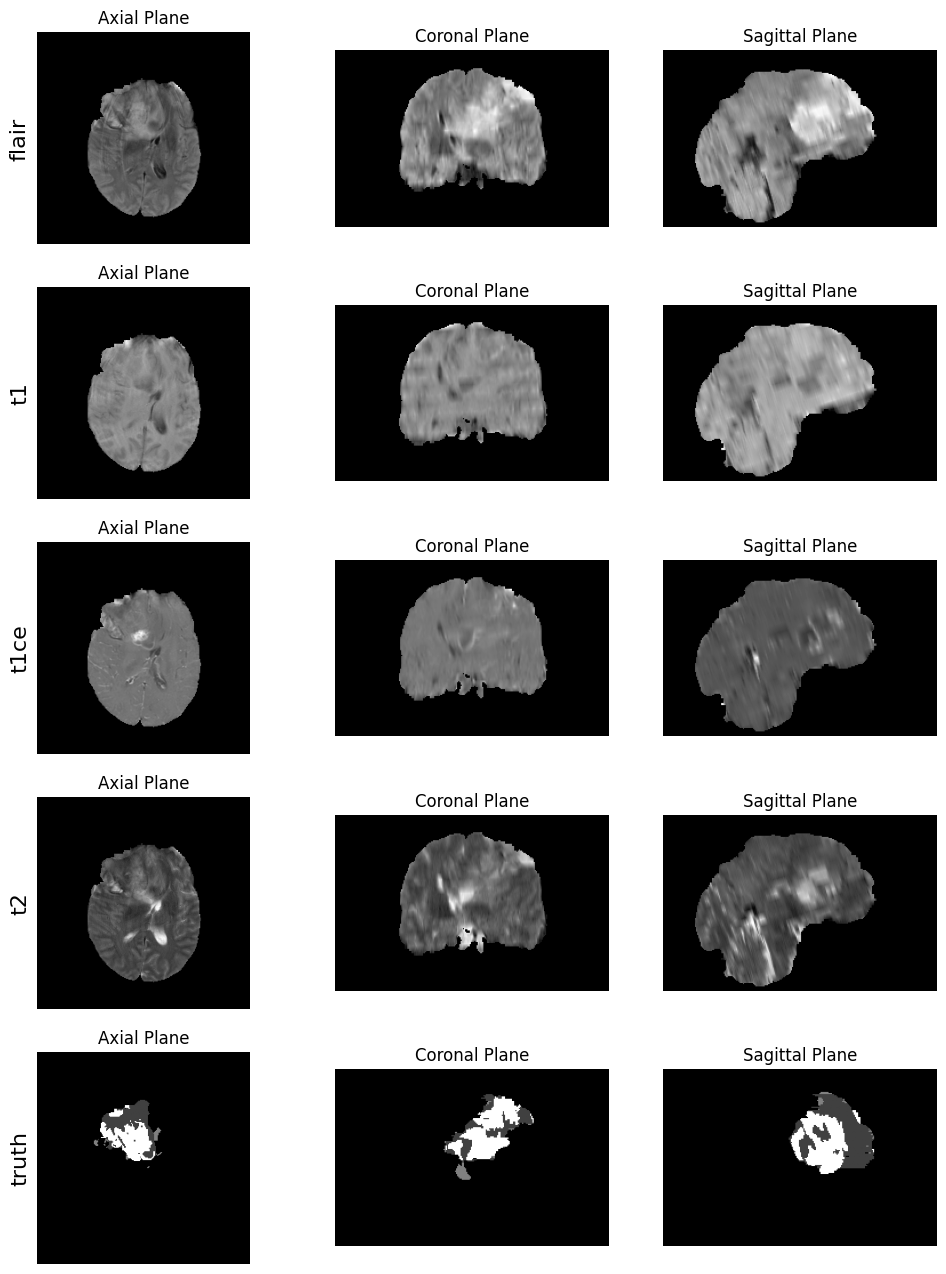

In [ ]:
plt.figure(figsize=(12, 16))

# Row 1: flair
plt.subplot(5, 3, 1)
plt.imshow(flair[:, :, central_axial].T, cmap='gray')
plt.title('Axial Plane')
plt.axis('off')
plt.text(-20, 120, 'flair', fontsize=16, ha='center', va='center', rotation=90)

plt.subplot(5, 3, 2)
plt.imshow(np.flip(flair[:, central_coronal, :]).T, cmap='gray')
plt.title('Coronal Plane')
plt.axis('off')

plt.subplot(5, 3, 3)
plt.imshow(np.flip(flair[central_sagittal, :, :].T), cmap='gray')
plt.title('Sagittal Plane')
plt.axis('off')

# Row 2: t1
plt.subplot(5, 3, 4)
plt.imshow(t1[:, :, central_axial].T, cmap='gray')
plt.title('Axial Plane')
plt.axis('off')
plt.text(-20, 120, 't1', fontsize=16, ha='center', va='center', rotation=90)

plt.subplot(5, 3, 5)
plt.imshow(np.flip(t1[:, central_coronal, :]).T, cmap='gray')
plt.title('Coronal Plane')
plt.axis('off')

plt.subplot(5, 3, 6)
plt.imshow(np.flip(t1[central_sagittal, :, :].T), cmap='gray')
plt.title('Sagittal Plane')
plt.axis('off')

# Row 3: t1ce
plt.subplot(5, 3, 7)
plt.imshow(t1ce[:, :, central_axial].T, cmap='gray')
plt.title('Axial Plane')
plt.axis('off')
plt.text(-20, 120, 't1ce', fontsize=16, ha='center', va='center', rotation=90)

plt.subplot(5, 3, 8)
plt.imshow(np.flip(t1ce[:, central_coronal, :]).T, cmap='gray')
plt.title('Coronal Plane')
plt.axis('off')

plt.subplot(5, 3, 9)
plt.imshow(np.flip(t1ce[central_sagittal, :, :].T), cmap='gray')
plt.title('Sagittal Plane')
plt.axis('off')

# Row 4: t2
plt.subplot(5, 3, 10)
plt.imshow(t2[:, :, central_axial].T, cmap='gray')
plt.title('Axial Plane')
plt.axis('off')
plt.text(-20, 120, 't2', fontsize=16, ha='center', va='center', rotation=90)

plt.subplot(5, 3, 11)
plt.imshow(np.flip(t2[:, central_coronal, :]).T, cmap='gray')
plt.title('Coronal Plane')
plt.axis('off')

plt.subplot(5, 3, 12)
plt.imshow(np.flip(t2[central_sagittal, :, :].T), cmap='gray')
plt.title('Sagittal Plane')
plt.axis('off')

# Row 5: truth
plt.subplot(5, 3, 13)
plt.imshow(truth[:, :, central_axial].T, cmap='gray')
plt.title('Axial Plane')
plt.axis('off')
plt.text(-20, 120, 'truth', fontsize=16, ha='center', va='center', rotation=90)

plt.subplot(5, 3, 14)
plt.imshow(np.flip(truth[:, central_coronal, :]).T, cmap='gray')
plt.title('Coronal Plane')
plt.axis('off')

plt.subplot(5, 3, 15)
plt.imshow(np.flip(truth[central_sagittal, :, :].T), cmap='gray')
plt.title('Sagittal Plane')
plt.axis('off')

plt.show()

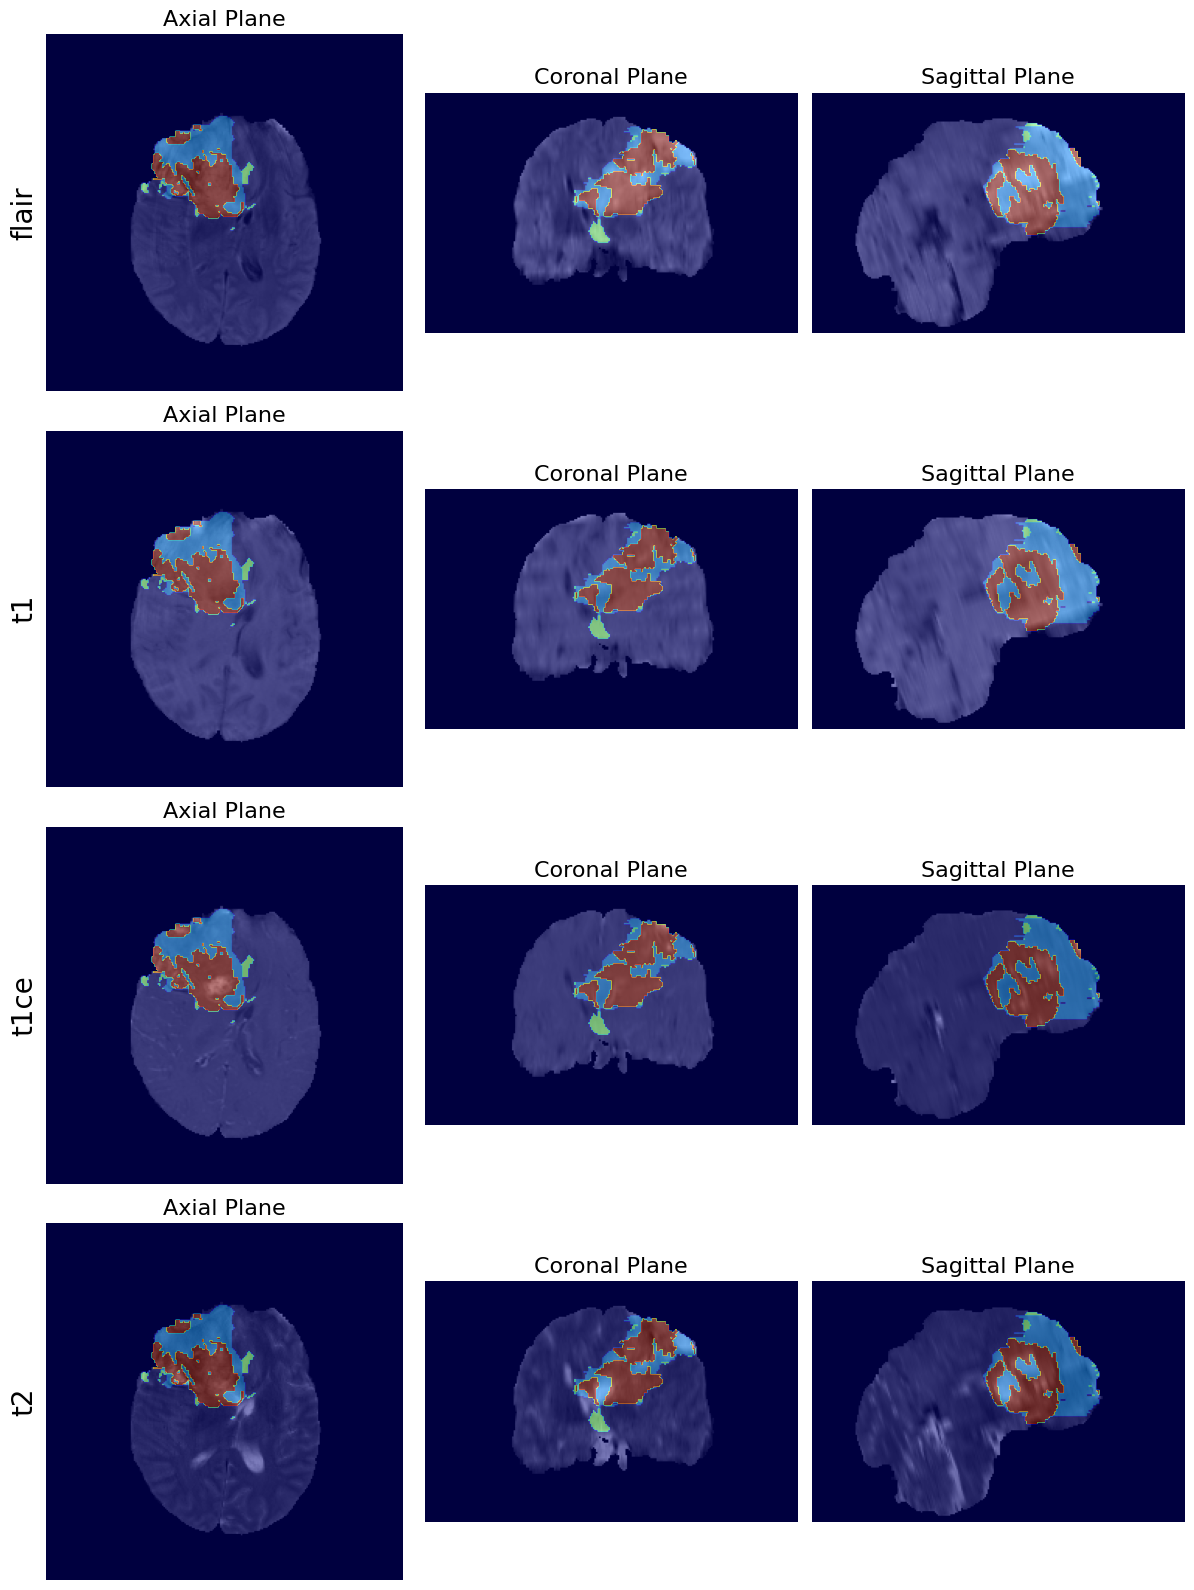

In [ ]:
# Create a plot with 3 horizontal subplots
fig, axes = plt.subplots(4, 3, figsize=(12, 16))


# Flair

axes[0, 0].text(-0.1, 0.5, 'flair', transform=axes[0, 0].transAxes,
                 fontsize=20, verticalalignment='center', rotation=90)

plot_overlay(flair, truth, central_axial, plane='axial', ax=axes[0, 0], rotate_image=-1, reverse_image=True)
axes[0, 0].set_title('Axial Plane', fontsize=16)

plot_overlay(flair, truth, central_coronal, plane='coronal', ax=axes[0, 1], rotate_image=1, reverse_image=True)
axes[0, 1].set_title('Coronal Plane', fontsize=16)

plot_overlay(flair, truth, central_sagittal, plane='sagittal', ax=axes[0, 2], rotate_image=1, reverse_image=True)
axes[0, 2].set_title('Sagittal Plane', fontsize=16)


# T1

axes[1, 0].text(-0.1, 0.5, 't1', transform=axes[1, 0].transAxes,
                 fontsize=20, verticalalignment='center', rotation=90)

plot_overlay(t1, truth, central_axial, plane='axial', ax=axes[1, 0], rotate_image=-1, reverse_image=True)
axes[1, 0].set_title('Axial Plane', fontsize=16)

plot_overlay(t1, truth, central_coronal, plane='coronal', ax=axes[1, 1], rotate_image=1, reverse_image=True)
axes[1, 1].set_title('Coronal Plane', fontsize=16)

plot_overlay(t1, truth, central_sagittal, plane='sagittal', ax=axes[1, 2], rotate_image=1, reverse_image=True)
axes[1, 2].set_title('Sagittal Plane', fontsize=16)


# T1ce

axes[2, 0].text(-0.1, 0.5, 't1ce', transform=axes[2, 0].transAxes,
                 fontsize=20, verticalalignment='center', rotation=90)

plot_overlay(t1ce, truth, central_axial, plane='axial', ax=axes[2, 0], rotate_image=-1, reverse_image=True)
axes[2, 0].set_title('Axial Plane', fontsize=16)

plot_overlay(t1ce, truth, central_coronal, plane='coronal', ax=axes[2, 1], rotate_image=1, reverse_image=True)
axes[2, 1].set_title('Coronal Plane', fontsize=16)

plot_overlay(t1ce, truth, central_sagittal, plane='sagittal', ax=axes[2, 2], rotate_image=1, reverse_image=True)
axes[2, 2].set_title('Sagittal Plane', fontsize=16)


# T2

axes[3, 0].text(-0.1, 0.5, 't2', transform=axes[3, 0].transAxes,
                 fontsize=20, verticalalignment='center', rotation=90)

plot_overlay(t2, truth, central_axial, plane='axial', ax=axes[3, 0], rotate_image=-1, reverse_image=True)
axes[3, 0].set_title('Axial Plane', fontsize=16)

plot_overlay(t2, truth, central_coronal, plane='coronal', ax=axes[3, 1], rotate_image=1, reverse_image=True)
axes[3, 1].set_title('Coronal Plane', fontsize=16)

plot_overlay(t2, truth, central_sagittal, plane='sagittal', ax=axes[3, 2], rotate_image=1, reverse_image=True)
axes[3, 2].set_title('Sagittal Plane', fontsize=16)

plt.tight_layout()
plt.show()

## Processing

This section is focused on managing, preprocessing, and generating data for training a ML model for 3D medical images segmentation.
Key operations include:
- Separating ground truth data from images.
- Normalizing and preprocessing the images.
- Applying data augmentation techniques to increase data variability and improve the model's generalization.
- Creating a data generator that provides continuously processed batches of data for training.

In [20]:
# Create two lists: one for the "truth" files and one for the remaining files without the "truth" file.

# List to store the "truth" files
files_truth = []

# List to store the remaining files
files_remaining = []

# Modify the existing list by removing the "truth" files and adding them to `files_truth`
for files_dict in files:
    files_dict_copy = files_dict.copy()

    if 'truth.nii.gz' in files_dict_copy:
        files_truth.append(files_dict_copy.pop('truth.nii.gz'))
        files_remaining.append(files_dict_copy)  # Add the dictionary without the "truth" file

# Verify the results
print(f"Found {len(files_truth)} truth files and {len(files_remaining)} sets of remaining files")
print("Example truth file and remaining files:")
print("{'truth.nii.gz': '" + files_truth[0] + "'}")
files_remaining[0]

Found 167 truth files and 167 sets of remaining files
Example truth file and remaining files:
{'truth.nii.gz': '/content/drive/MyDrive/BRATS/Pre-operative_TCGA_GBM_NIfTI_and_Segmentations/TCGA-12-0616/truth.nii.gz'}


{'flair.nii.gz': '/content/drive/MyDrive/BRATS/Pre-operative_TCGA_GBM_NIfTI_and_Segmentations/TCGA-12-0616/flair.nii.gz',
 't1.nii.gz': '/content/drive/MyDrive/BRATS/Pre-operative_TCGA_GBM_NIfTI_and_Segmentations/TCGA-12-0616/t1.nii.gz',
 't1ce.nii.gz': '/content/drive/MyDrive/BRATS/Pre-operative_TCGA_GBM_NIfTI_and_Segmentations/TCGA-12-0616/t1ce.nii.gz',
 't2.nii.gz': '/content/drive/MyDrive/BRATS/Pre-operative_TCGA_GBM_NIfTI_and_Segmentations/TCGA-12-0616/t2.nii.gz'}

In [21]:
# Use the ground truth images to check the presence of the tumor
count_with_tumor, count_without_tumor = count_tumor_presence(files_truth)

print(f"Number of images with tumor: {count_with_tumor}")
print(f"Number of images without tumor: {count_without_tumor}")

KeyboardInterrupt: 

In [22]:
DIM_CHANNEL_80 = (80, 80, 48)
DIM_IMAGE_80 = (80, 80, 46, 4)

# Define the new dimensions, as the 25% of the originals
DIM_CHANNEL = (60, 60, 36)
DIM_IMAGE = (60, 60, 36, 4)

In [24]:
# Two dictionaries, channel_to_dimension and dimension_to_channel, are created to associate the channel names with their respective dimensions and vice versa.
# This is useful for processing and managing multidimensional images.

channel_to_dimension = {
    channel: index for index, channel in enumerate(channel_names)
}
dimension_to_channel = {
    index: channel for index, channel in enumerate(channel_names)
}
print("Channel to dimension:", channel_to_dimension)
print("Dimension to channel:", dimension_to_channel)

Channel to dimension: {'flair.nii.gz': 0, 't1.nii.gz': 1, 't1ce.nii.gz': 2, 't2.nii.gz': 3}
Dimension to channel: {0: 'flair.nii.gz', 1: 't1.nii.gz', 2: 't1ce.nii.gz', 3: 't2.nii.gz'}


In [25]:
# Load an image, consisting of a truth file and a set of channels, and return the truth tensor and the overall image.

def load_channel(channel_path: str) -> np.ndarray:
    channel_image = nib.nifti1.load(channel_path)
    channel_tensor = channel_image.get_fdata(dtype=np.float32)
    # Resizes the channel tensor to a 25% downsampled version of the original size while maintaining spatial integrity.
    channel_tensor = channel_tensor[:,:,6:150].reshape((4,60,4,60,4,36),order='F')
    channel_tensor = np.mean(np.mean(np.mean(channel_tensor,axis=-2),axis=-3),axis=0)
    return channel_tensor

def load_channel_80(channel_path: str) -> np.ndarray:
    channel_image = nib.nifti1.load(channel_path)
    channel_tensor = channel_image.get_fdata(dtype=np.float32)
    channel_tensor = channel_tensor[:,:,6:150].reshape((3,80,3,80,3,48),order='F')
    channel_tensor = np.mean(np.mean(np.mean(channel_tensor,axis=-2),axis=-3),axis=0)

    return channel_tensor



def load_image(path_truth: str, path_channels: dict[str, str]) -> tuple[np.ndarray, np.ndarray]:
    image_tensor = np.zeros(DIM_IMAGE, dtype=np.float32)
    for channel, path in path_channels.items():
        image_tensor[:,:,:,channel_to_dimension[channel]] = load_channel(path)
    return load_channel(path_truth), image_tensor

In [26]:
# These functions converts just the ground truth data into a format suitable for machine learning models.
# `truth_to_boolean` processes a ground truth tensor by transforming its values into one-hot encoded categories (e.g., 0, 1, 2, 3), making it compatible with classification tasks in neural networks.


def truth_to_boolean(truth_tensor: np.ndarray) -> np.ndarray:
    # Cap intensity values greater than 3.5 at 3, as the expected categories are 0, 1, 2, 3.
    truth_tensor[truth_tensor > 3.5] = 3
    # keras.to_categorical converts the tensor into one-hot encoded format with 4 categories (0, 1, 2, 3).
    return keras.utils.to_categorical(truth_tensor, num_classes = 4)


In [27]:
# These functions are used to normalize the intensity values of 3D medical images.
#gaussian_intensity and gaussian_all are created to transform the data along a gaussian distribution
#min_max_all and min_max are create to transform the data in a range(0,1)
#intensity_avg and intensity_avg_all are used to transform the data using the median

def gaussian_intensity(channel_tensor: np.ndarray) -> np.ndarray:

  mean = np.mean(channel_tensor)
  sd = np.std(channel_tensor)
  return (channel_tensor - mean) / sd

def gaussian_all(image_tensor: np.ndarray) -> np.ndarray:

    return np.stack([

        gaussian_intensity(image_tensor[:,:,:,i])
        for i in range(image_tensor.shape[-1])
    ], axis = -1) # stack the results in the list in the last dime

def min_max(channel_tensor: np.ndarray):
  massimo = np.max(channel_tensor)
  minimo = np.min(channel_tensor)
  return((channel_tensor-minimo)/(massimo-minimo))

def min_max_all(image_tensor: np.ndarray) -> np.ndarray:

    return np.stack([
        # cal `intensity_avg` for each channel (in the last dimension)
        min_max(image_tensor[:,:,:,i])
        for i in range(image_tensor.shape[-1])
    ], axis = -1) # stack the results in the list in the last dimension to keep the same shape of input



def intensity_avg(channel_tensor: np.ndarray) -> np.ndarray:

    # threshold value for intensity values
    threshold = np.percentile(channel_tensor, 1)

    # median of intensity values that are over the threshold
    median = np.percentile(channel_tensor[channel_tensor > threshold], 50)
    return (channel_tensor - 0.5*median) / median

def intensity_avg_all(image_tensor: np.ndarray) -> np.ndarray:

    return np.stack([
        # cal `intensity_avg` for each channel (in the last dimension)
        intensity_avg(image_tensor[:,:,:,i])
        for i in range(image_tensor.shape[-1])
    ], axis = -1) # stack the results in the list in the last dimension to keep the same shape of input



In [28]:
# Definition of the data augmentation techniques

def flip(volume, axis = 1):
    return np.flip(volume, axis = axis)

def data_augmentation(truth_tensor: np.ndarray, image_tensor: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    # Applies random flipping to augment the dataset and increase model robustness. This ensures better generalization to unseen data.
    if random.random() < 0.5:
      image_tensor = tf.numpy_function(flip, [image_tensor], tf.float32)
      truth_tensor = tf.numpy_function(flip, [truth_tensor], tf.float32)

    return truth_tensor, image_tensor

In [29]:
# This function allows to create a data pipeline that feeds batches of image data and ground truth labels to the models, optionally applying data augmentation techniques.
def get_dataset_generator(files_truth_list: list[str], files_input_list: list[dict[str,str]], augmentation = True):

    # Generates data without applying augmentation. The data will be fed to the network
    def dataset_generator_without_augmentation():
        for i in range(len(files_truth_list)):
            # Load and preprocess tensors
            truth_tensor, image_tensor = load_image(files_truth_list[i], files_input_list[i])
            image_tensor = intensity_avg_all(image_tensor)
            #image_tensor = min_max_all(image_tensor)
            truth_tensor = truth_to_boolean(truth_tensor)
            yield tf.convert_to_tensor(image_tensor), tf.convert_to_tensor(truth_tensor)

    # Generates data with augmentation. The data will be fed to the network
    def dataset_generator_with_augmentation():
        for i in range(len(files_truth_list)):
            # Load and preprocess tensors
            truth_tensor, image_tensor = load_image(files_truth_list[i], files_input_list[i])
            image_tensor = intensity_avg_all(image_tensor)
            truth_tensor = truth_to_boolean(truth_tensor)
            truth_tensor, image_tensor = data_augmentation(truth_tensor, image_tensor)
            yield tf.convert_to_tensor(image_tensor), tf.convert_to_tensor(truth_tensor)

    # Choose generator based on augmentation flag
    return dataset_generator_with_augmentation if augmentation else dataset_generator_without_augmentation

print(get_dataset_generator(files_truth, files_remaining)().send(None))

(<tf.Tensor: shape=(60, 60, 36, 4), dtype=float32, numpy=
array([[[[-0.5, -0.5, -0.5, -0.5],
         [-0.5, -0.5, -0.5, -0.5],
         [-0.5, -0.5, -0.5, -0.5],
         ...,
         [-0.5, -0.5, -0.5, -0.5],
         [-0.5, -0.5, -0.5, -0.5],
         [-0.5, -0.5, -0.5, -0.5]],

        [[-0.5, -0.5, -0.5, -0.5],
         [-0.5, -0.5, -0.5, -0.5],
         [-0.5, -0.5, -0.5, -0.5],
         ...,
         [-0.5, -0.5, -0.5, -0.5],
         [-0.5, -0.5, -0.5, -0.5],
         [-0.5, -0.5, -0.5, -0.5]],

        [[-0.5, -0.5, -0.5, -0.5],
         [-0.5, -0.5, -0.5, -0.5],
         [-0.5, -0.5, -0.5, -0.5],
         ...,
         [-0.5, -0.5, -0.5, -0.5],
         [-0.5, -0.5, -0.5, -0.5],
         [-0.5, -0.5, -0.5, -0.5]],

        ...,

        [[-0.5, -0.5, -0.5, -0.5],
         [-0.5, -0.5, -0.5, -0.5],
         [-0.5, -0.5, -0.5, -0.5],
         ...,
         [-0.5, -0.5, -0.5, -0.5],
         [-0.5, -0.5, -0.5, -0.5],
         [-0.5, -0.5, -0.5, -0.5]],

        [[-0.5, -0.5, -0

## Data Visualization

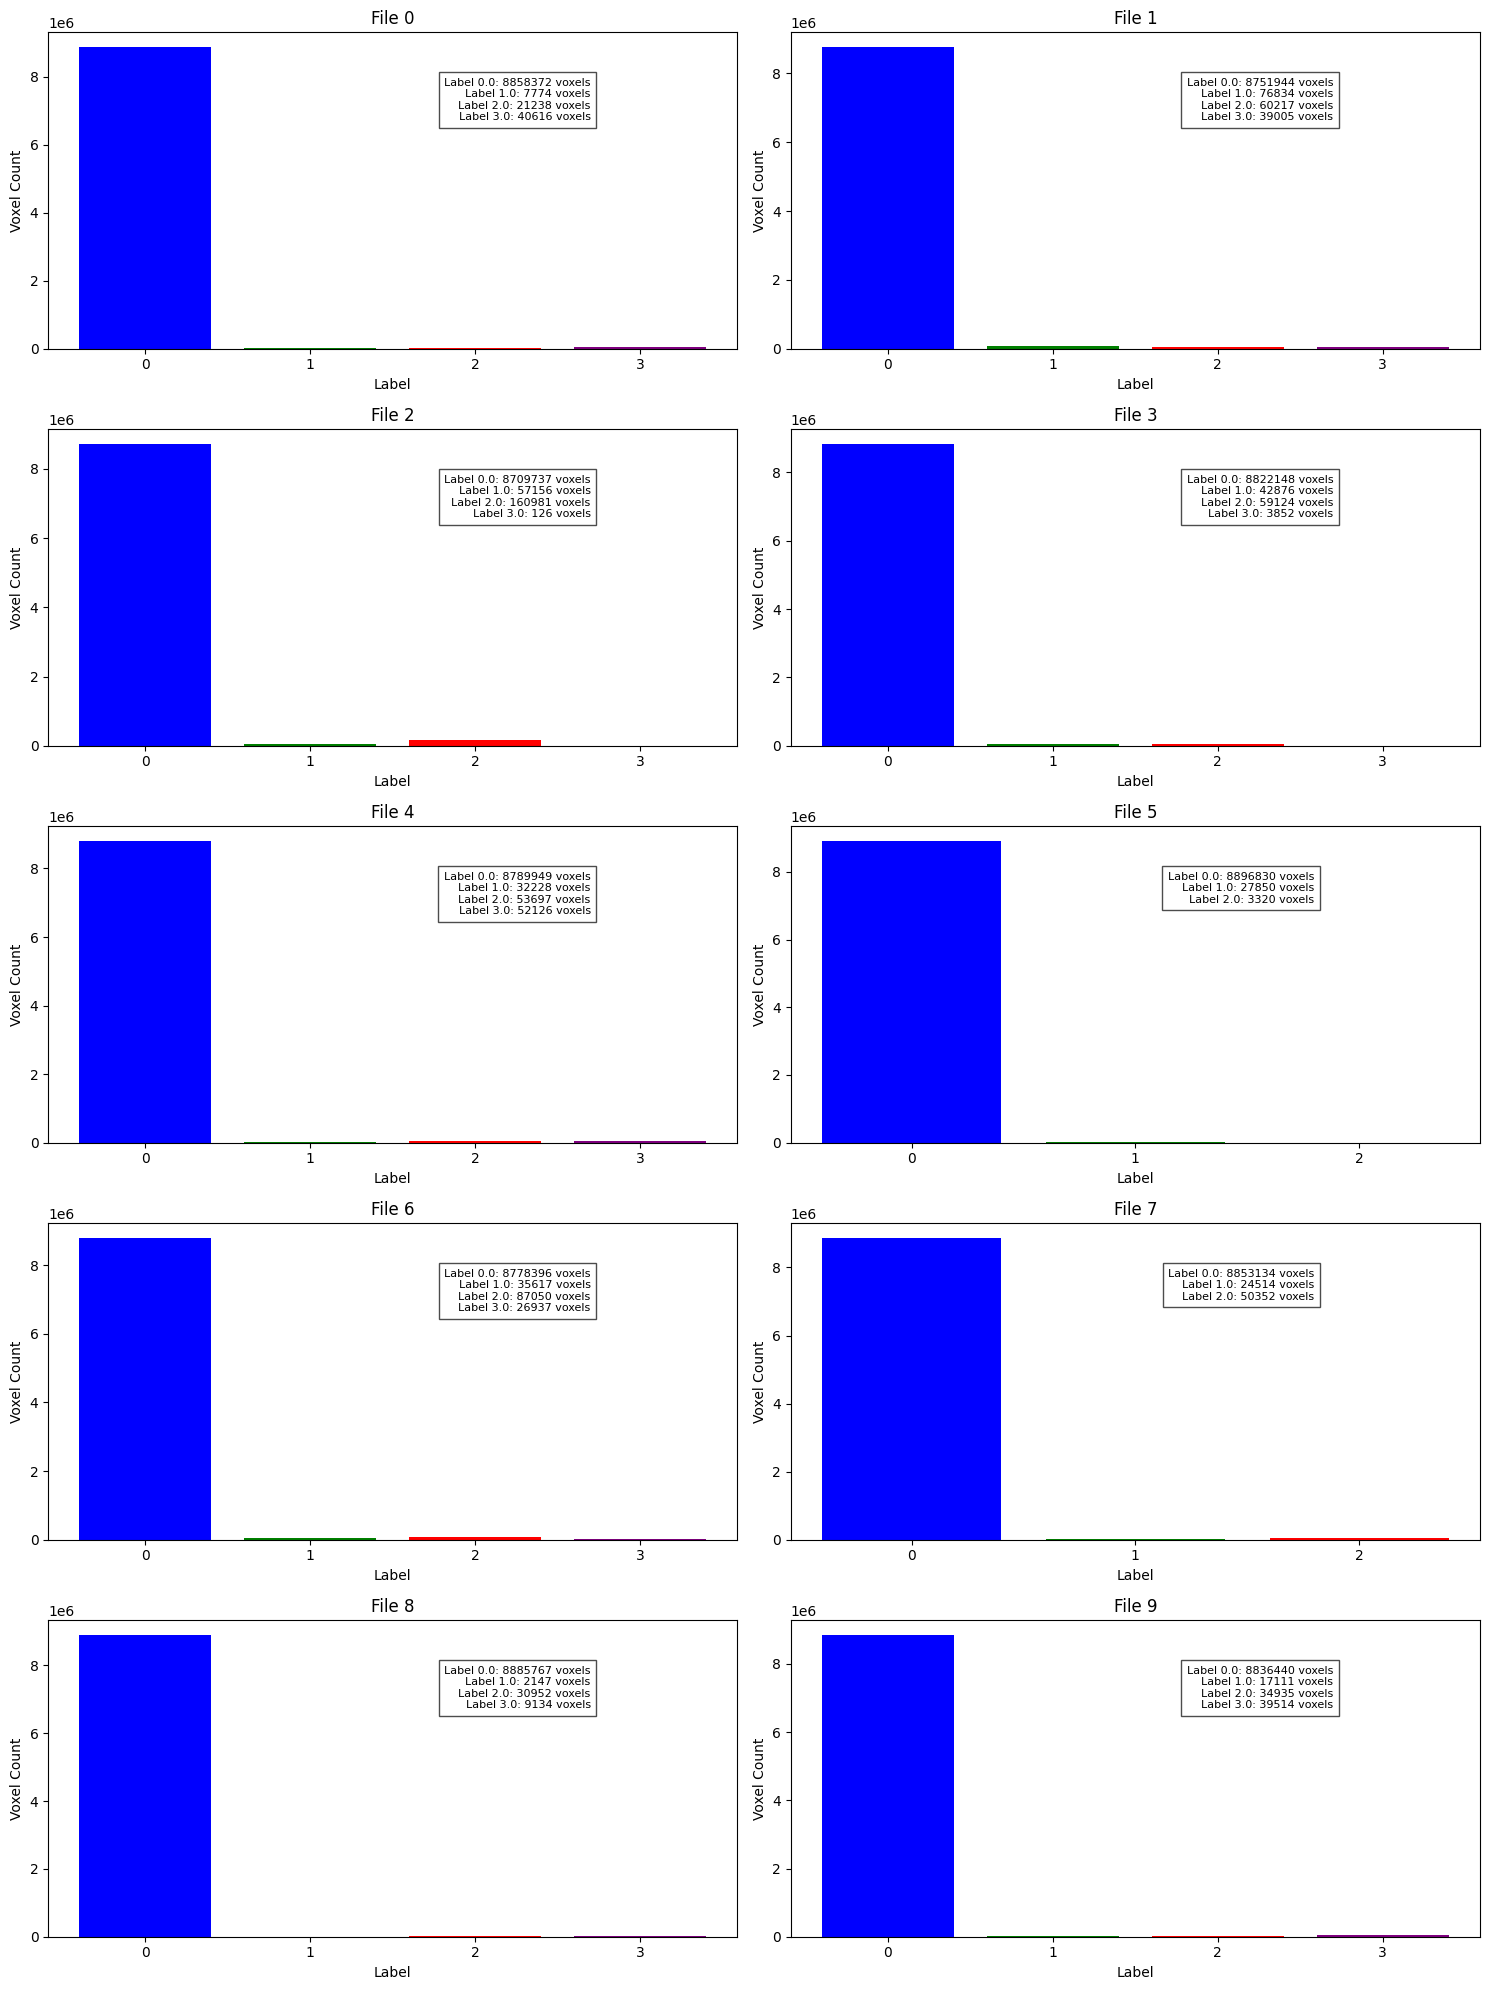

In [30]:
# Create a figure with 2 columns and 5 rows for subplots
fig, axes = plt.subplots(5, 2, figsize=(15, 20))  # Adjust figure size as needed
axes = axes.flatten()  # Flatten the 2D array of axes for easier indexing

# Iterate through the files in files_truth
for i in range(10):
    # Compute the unique labels and their voxel counts
    segmentation_data = nib.load(files_truth[i]).get_fdata()
    segmentation_data[segmentation_data == 4] = 3  # Convert label "4" to "3" just for this case
    unique, counts = np.unique(segmentation_data, return_counts=True)
    label_distribution = dict(zip(unique, counts))

    # Visualize the label distribution in the corresponding subplot
    ax = axes[i]
    ax.bar(label_distribution.keys(), label_distribution.values(), color=['blue', 'green', 'red', 'purple'])
    ax.set_title(f"File {i}")
    ax.set_xlabel("Label")
    ax.set_ylabel("Voxel Count")
    ax.set_xticks(list(label_distribution.keys()))  # Ensure x-axis shows only integers

    # Print the label distribution in the top-right corner of the corresponding subplot
    text_y = max(label_distribution.values()) * 0.9  # Adjust y-position for the text
    text_x = max(label_distribution.keys()) * 0.9  # Adjust x-position to place it in the top-right corner
    distribution_text = "\n".join([f"Label {label}: {count} voxels" for label, count in label_distribution.items()])
    ax.text(text_x, text_y, distribution_text, fontsize=8, verticalalignment='top', horizontalalignment='right', bbox=dict(facecolor='white', alpha=0.7))

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

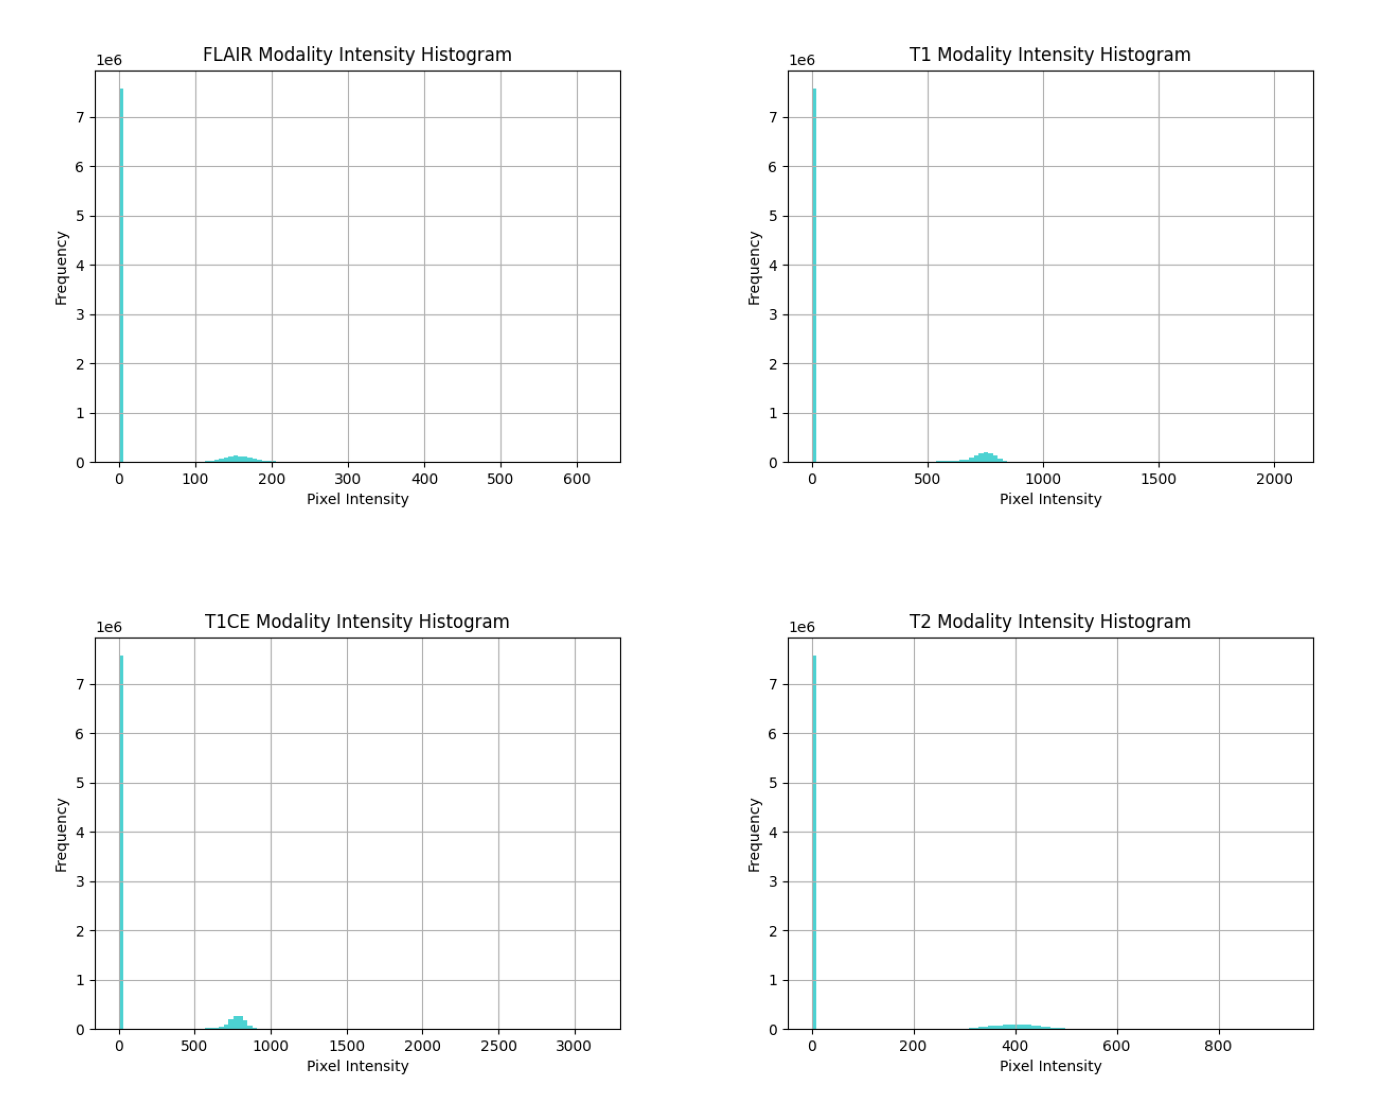

In [ ]:
# Function to plot and save the histogram to an in-memory buffer
def plot_intensity_histogram_to_buffer(image_array, title, bins=100):
    buffer = io.BytesIO()  # Create in-memory buffer

    plt.hist(image_array.flatten(), bins=bins, color='c', alpha=0.7)
    plt.title(title)
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Frequency")
    plt.grid(True)

    plt.savefig(buffer, format='png')  # Save plot to the buffer in PNG format
    plt.close()  # Close the plot to free memory

    buffer.seek(0)  # Reset the buffer position for reading later
    return buffer

# Function to generate histograms for all modalities, except segmentation
def generate_histograms_from_arrays(flair_array, t1_array, t1ce_array, t2_array):
    buffers = {}  # Dictionary to store the buffers for each modality

    buffers['FLAIR'] = plot_intensity_histogram_to_buffer(flair_array, "FLAIR Modality Intensity Histogram")
    buffers['T1'] = plot_intensity_histogram_to_buffer(t1_array, "T1 Modality Intensity Histogram")
    buffers['T1CE'] = plot_intensity_histogram_to_buffer(t1ce_array, "T1CE Modality Intensity Histogram")
    buffers['T2'] = plot_intensity_histogram_to_buffer(t2_array, "T2 Modality Intensity Histogram")

    return buffers

# Generate the histograms and store them in memory buffers
histogram_buffers = generate_histograms_from_arrays(nib.load(files_remaining[0]['flair.nii.gz']).get_fdata(), nib.load(files_remaining[0]['t1.nii.gz']).get_fdata(),
                                                    nib.load(files_remaining[0]['t1ce.nii.gz']).get_fdata(), nib.load(files_remaining[0]['t2.nii.gz']).get_fdata())

# Create subplots (2x2 grid) and plot each modality's histogram
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Load images from buffers and display them in the subplots
for i, (ax, modality) in enumerate(zip(axes.flat, ['FLAIR', 'T1', 'T1CE', 'T2'])):
    # Load image from the in-memory buffer using PIL
    image = Image.open(histogram_buffers[modality])

    # Display the image on the subplot
    ax.imshow(image)

    # Turn off the axis labels (optional, for cleaner display)
    ax.axis('off')

# Adjust layout
plt.tight_layout()
plt.show()

In [ ]:
def compute_region_statistics(image_array, seg_array, label):
    region_mask = seg_array == label
    region_values = image_array[region_mask]

    mean_intensity = np.mean(region_values)
    std_intensity = np.std(region_values)

    print(f"Region {label} - Mean intensity: {mean_intensity:.2f}, Std: {std_intensity:.2f}")
    return mean_intensity, std_intensity
# Example: Compute statistics for each tumor region on the FLAIR modality
labels = [0, 1, 2, 4]  # Labels in the segmentation mask

# Iterate through files in files_truth from 0 to 9
for i in range(10):  # Assuming you want to process files 0 to 9
    # Load the image and segmentation data for the current index
    image_data = nib.load(files_remaining[i]['flair.nii.gz']).get_fdata()
    seg_data = nib.load(files_truth[i]).get_fdata()
    print(f"\nFile {i}:")
    # Compute statistics for each tumor region
    for label in labels:
        compute_region_statistics(image_data, seg_data, label)


File 0:
Region 0 - Mean intensity: 19.70, Std: 51.78
Region 1 - Mean intensity: 295.70, Std: 42.30
Region 2 - Mean intensity: 277.22, Std: 55.36
Region 4 - Mean intensity: 304.61, Std: 35.63

File 1:
Region 0 - Mean intensity: 31.53, Std: 77.01
Region 1 - Mean intensity: 208.70, Std: 23.45
Region 2 - Mean intensity: 271.27, Std: 23.88
Region 4 - Mean intensity: 266.94, Std: 31.21

File 2:
Region 0 - Mean intensity: 18.74, Std: 44.47
Region 1 - Mean intensity: 220.44, Std: 49.48
Region 2 - Mean intensity: 243.72, Std: 48.71
Region 4 - Mean intensity: 216.77, Std: 38.50

File 3:
Region 0 - Mean intensity: 15.84, Std: 38.28
Region 1 - Mean intensity: 255.35, Std: 36.88
Region 2 - Mean intensity: 183.95, Std: 36.21
Region 4 - Mean intensity: 220.18, Std: 42.28

File 4:
Region 0 - Mean intensity: 36.10, Std: 94.72
Region 1 - Mean intensity: 379.42, Std: 96.23
Region 2 - Mean intensity: 394.09, Std: 58.71
Region 4 - Mean intensity: nan, Std: nan

File 5:
Region 0 - Mean intensity: 55.97, St

In [ ]:
# Plot 3D volume of FLAIR modality
flair_threshold = 100  # You can adjust this threshold based on intensity
ipv.quickvolshow(nib.load(files_remaining[0]['flair.nii.gz']).get_fdata(), level=[0.1, 0.4], opacity=0.2)
ipv.show()

# Plot 3D visualization of the segmentation mask
# You can use specific labels for different parts of the tumor
seg_mask_3d = nib.load(files_truth[0]).get_fdata().copy()
seg_mask_3d[seg_mask_3d == 0] = np.nan  # Set background to NaN for visualization
ipv.quickvolshow(seg_mask_3d, level=[1, 2, 3, 4], opacity=0.5)
ipv.show()

Container(children=[VBox(children=(HBox(children=(Label(value='levels:'), FloatSlider(value=0.1, max=1.0, step…

Container(children=[VBox(children=(HBox(children=(Label(value='levels:'), FloatSlider(value=1.0, max=1.0, step…

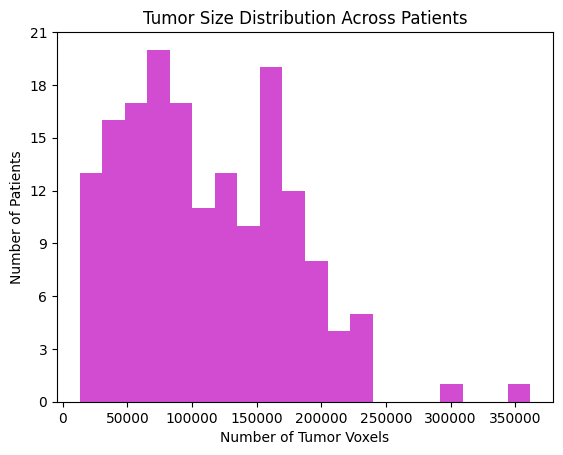

Mean tumor size: 111628.99 voxels
Max tumor size: 361783 voxels
Min tumor size: 12952 voxels


In [ ]:
tumor_sizes = []

# Loop over all patients to compute tumor sizes
for i in range(len(files)):
    seg_image = files_truth[i]
    seg_array = nib.load(files_truth[i]).get_fdata()

    # Compute tumor size (number of voxels where label > 0)
    tumor_size = np.sum(seg_array > 0)
    tumor_sizes.append(tumor_size)

# Visualize the tumor size distribution
plt.hist(tumor_sizes, bins=20, color='m', alpha=0.7)
plt.title("Tumor Size Distribution Across Patients")
plt.xlabel("Number of Tumor Voxels")
plt.ylabel("Number of Patients")
# Set y-axis to show only integer values
plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))
plt.show()

# Print statistics
print(f"Mean tumor size: {np.mean(tumor_sizes):.2f} voxels")
print(f"Max tumor size: {np.max(tumor_sizes)} voxels")
print(f"Min tumor size: {np.min(tumor_sizes)} voxels")


In [ ]:
# Show the correlation between these modalities for the first case
# Extract the region mask for the region of interest (label 4)
region_mask = seg_array == 4

# Load the data for the different imaging modalities
modalities = {
    "FLAIR": nib.load(files_remaining[0]['flair.nii.gz']).get_fdata()[region_mask],
    "T1": nib.load(files_remaining[0]['t1.nii.gz']).get_fdata()[region_mask],
    "T1CE": nib.load(files_remaining[0]['t1ce.nii.gz']).get_fdata()[region_mask],
    "T2": nib.load(files_remaining[0]['t2.nii.gz']).get_fdata()[region_mask]
}

# Create an empty correlation matrix using modality names as both row and column labels
correlation_matrix = pd.DataFrame(index=modalities.keys(), columns=modalities.keys())

# Compute Pearson correlation for each modality pair
for mod1, values1 in modalities.items():
    for mod2, values2 in modalities.items():
        # Calculate Pearson correlation for each unique pair, skipping diagonal (auto-correlation)
        if mod1 == mod2:
            correlation_matrix.loc[mod1, mod2] = 1.00  # Autocorrelation is always 1
        elif pd.isna(correlation_matrix.loc[mod1, mod2]):
            correlation, _ = pearsonr(values1.flatten(), values2.flatten())
            correlation = round(correlation, 2)  # Round the correlation to 2 decimal places
            correlation_matrix.loc[mod1, mod2] = correlation
            correlation_matrix.loc[mod2, mod1] = correlation  # Symmetry of the matrix

# Print the correlation matrix
print("Correlation Matrix (Pearson):\n")

try:
    display(correlation_matrix)
except ImportError:
    pass

Correlation Matrix (Pearson):



,FLAIR,T1,T1CE,T2
FLAIR,1.0,0.71,0.61,0.67
T1,0.71,1.0,0.87,0.57
T1CE,0.61,0.87,1.0,0.45
T2,0.67,0.57,0.45,1.0


- High Correlation (T1 and T1CE: 0.87): T1 and T1CE sequences are highly similar, with T1CE providing contrast enhancement for better visualization of tumor regions.
- Moderate Correlation (FLAIR with T1, T1CE, and T2): FLAIR shares moderate positive relationships with other modalities, emphasizing its unique role in highlighting edema and non-enhancing tumors.
- Moderate Correlation (T1 and T2: 0.57): T1 and T2 provide complementary contrasts, with T1 highlighting fat and T2 highlighting water content.
- Lower Correlation (T1CE and T2: 0.45): T1CE focuses on contrast-enhancing areas, while T2 emphasizes fluid and edema, offering distinct but complementary information.

Modality T1CE has 99.69% background
Modality T1 has 99.61% background
Modality T2 has 99.14% background
Modality FLAIR has 86.34% background
The image with the most background is: T1CE


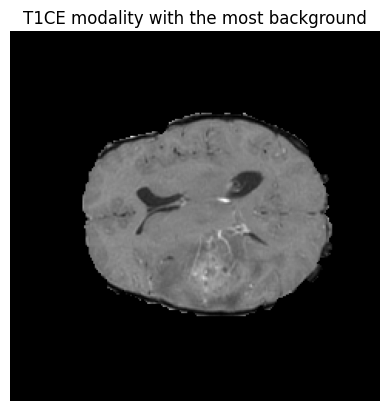

In [ ]:
# Function to calculate the percentage of background_pixel
def calculate_background_percentage(image_array, low_threshold=10, high_threshold=240):
    # count the pixel
    low_background = np.sum(image_array < low_threshold)  # low-intensity pixel
    high_background = np.sum(image_array > high_threshold)  # high-intensity pixel

    total_pixels = image_array.size

    background_percentage = (low_background + high_background) / total_pixels * 100
    return background_percentage


def find_images_with_most_background(flair_array, t1_array, t1ce_array, t2_array):

    background_percentages = {
        'FLAIR': calculate_background_percentage(flair_array),
        'T1': calculate_background_percentage(t1_array),
        'T1CE': calculate_background_percentage(t1ce_array),
        'T2': calculate_background_percentage(t2_array)
    }


    sorted_modalities = sorted(background_percentages.items(), key=lambda x: x[1], reverse=True)

    return sorted_modalities

# find the images with most background
images_with_most_background = find_images_with_most_background(nib.load(files_remaining[0]['flair.nii.gz']).get_fdata(), nib.load(files_remaining[0]['t1.nii.gz']).get_fdata(),
                                                               nib.load(files_remaining[0]['t1ce.nii.gz']).get_fdata(), nib.load(files_remaining[0]['t2.nii.gz']).get_fdata())


for modality, percentage in images_with_most_background:
    print(f"Modality {modality} has {percentage:.2f}% background")

# visualization of the images with the most background
top_modality = images_with_most_background[0][0]
print(f"The image with the most background is: {top_modality}")

# show the correspondent images
if top_modality == 'FLAIR':
    plt.imshow(nib.load(files_remaining[0]['flair.nii.gz']).get_fdata()[:, :, nib.load(files_remaining[0]['flair.nii.gz']).get_fdata().shape[2] // 2], cmap='gray')
elif top_modality == 'T1':
    plt.imshow(nib.load(files_remaining[0]['t1.nii.gz']).get_fdata()[:, :, nib.load(files_remaining[0]['t1.nii.gz']).get_fdata().shape[2] // 2], cmap='gray')
elif top_modality == 'T1CE':
    plt.imshow(nib.load(files_remaining[0]['t1ce.nii.gz']).get_fdata()[:, :, nib.load(files_remaining[0]['t1ce.nii.gz']).get_fdata().shape[2] // 2], cmap='gray')
elif top_modality == 'T2':
    plt.imshow(nib.load(files_remaining[0]['t2.nii.gz']).get_fdata()[:, :, nib.load(files_remaining[0]['t2.nii.gz']).get_fdata().shape[2] // 2], cmap='gray')

plt.title(f'{top_modality} modality with the most background')
plt.axis('off')
plt.show()

## Preparation

In this section:

- The dataset is split into three parts: training , testing and validation .
- The number of files for each split is calculated based on the predefined proportions, ensuring the total number of files matches the original dataset size.
- The file lists (files_remaining and files_truth) are sliced into subsets for training, testing, and validation according to the calculated numbers.
- Input and output dimensions for the neural network model are defined using TensorFlow, with the shape specified by DIM_IMAGE and data type set to np.float32.
- TensorFlow datasets are created using dataset generators for training, testing, and validation, ensuring the datasets contain the correct number of samples using assert_cardinality.
- The number of epochs and learning rate for training are defined.
- The input layer for the Keras model is set up, and the number of output channels is extracted from the image dimensions.

In [37]:
# These variables define the proportions of the dataset to be used for training, testing, and validation.
PERCENT_TRAINING = 0.8
PERCENT_TESTING = 0.1
PERCENT_VALIDATION = 0.1

In [38]:
# Here the number of files to allocate in each dataset split is computed

n_train = round(PERCENT_TRAINING*len(files))
n_test = round(PERCENT_TESTING*len(files))
n_val = round(PERCENT_VALIDATION*len(files))

# Ensures that the sum of the datasets equals the total number of files available. If not, the difference is added to the training set
total_count = n_train + n_test + n_val
if total_count != len(files):
    difference = len(files) - total_count
    n_train += difference

print("Training data:", n_train, "\nTest data:", n_test, "\nValidation data:", n_val)

Training data: 133 
Test data: 17 
Validation data: 17


In [39]:
# This code splits the remaining files and ground truth files into training, testing, and validation sets based on the previously calculated numbers.
# It slices the lists (`files_remaining` and `files_truth`) into corresponding subsets for each dataset.

files_training = files_remaining[:n_train]
files_truth_training = files_truth[:n_train]

files_testing = files_remaining[n_train:n_train + n_test]
files_truth_testing = files_truth[n_train:n_train + n_test]

files_validation = files_remaining[n_train + n_test:]
files_truth_validation = files_truth[n_train + n_test:]

In [40]:
# This code defines the input and output dimensions for the neural network model.
# - `dimension_net_input`: Specifies the input tensor shape and data type for the model. It uses `DIM_IMAGE` for the shape and `np.float32` as the data type.
# - `dimension_net_output`: Specifies the output tensor shape and data type, which is the same as the input in this case.

dimension_net_input = tf.TensorSpec(DIM_IMAGE, dtype=np.float32)
dimension_net_output = tf.TensorSpec(DIM_IMAGE, dtype=np.float32)
generator_output_signature = (dimension_net_input, dimension_net_output)
generator_output_signature

(TensorSpec(shape=(60, 60, 36, 4), dtype=tf.float32, name=None),
 TensorSpec(shape=(60, 60, 36, 4), dtype=tf.float32, name=None))

In [46]:
# This code creates TensorFlow datasets for training, testing, and validation using the dataset generators and uses the previously defined `generator_output_signature` for input and output shapes.
dataset_training = tf.data.Dataset.from_generator(
    get_dataset_generator(files_truth_training, files_training, augmentation = False),
    output_signature = generator_output_signature,
)
# set cardinality for better progress
dataset_training = dataset_training.apply(tf.data.experimental.assert_cardinality(len(files_training)))

dataset_testing = tf.data.Dataset.from_generator(
    get_dataset_generator(files_truth_testing, files_testing, augmentation = False),
    output_signature = generator_output_signature,
)
dataset_testing = dataset_testing.apply(tf.data.experimental.assert_cardinality(len(files_testing)))

dataset_validation = tf.data.Dataset.from_generator(
    get_dataset_generator(files_truth_validation, files_validation, augmentation = False),
    output_signature = generator_output_signature,
)
dataset_validation = dataset_validation.apply(tf.data.experimental.assert_cardinality(len(files_validation)))

In [31]:
# Here we define the number of epochs and the learning rate to be applied at each model.

NUM_EPOCH = 3
LEARNING_RATE = 0.001

In [32]:
# Here we define the input layer for a Keras model and extracts the number of output channels.

inputs = keras.Input(DIM_IMAGE)
out_chans = DIM_IMAGE[3]

## Models training

### ResNet

ResNet3D is a deep convolutional neural network (CNN) model designed for 3D image segmentation and pattern recognition. It extends traditional ResNet architectures, which use residual blocks to facilitate training deep networks by mitigating the vanishing gradient problem.

Key features of ResNet3D:

- Residual Blocks: Skip connections allow deeper networks to be trained efficiently.
- 3D Convolutions: It operates on 3D data (e.g., medical scans), capturing spatial relationships in depth, width, and height.
- Applications: ResNet3D excels in segmentation tasks like tumor detection in medical imaging and pattern recognition for classifying 3D structures.
- Advantages: It enables deep networks with improved performance, generalization, and efficiency on volumetric data.

ResNet3D is especially effective in analyzing complex 3D data like MRI scans, making it a powerful tool for automated medical diagnosis and other volumetric image analysis tasks.

(The one below is a 3D ResNet implementation that utilizes bottleneck residual blocksù. The architecture starts with an initial 3D convolutional layer, followed by four bottleneck residual blocks with increasing filter sizes (64, 64, 128, 256). Each bottleneck block reduces and then expands the dimensionality of the feature maps to improve efficiency while preserving representational power. A final 3D convolutional layer is applied to produce the output with the desired number of classes using a softmax activation.

We initially used this version, but later switched to another architecture that delivered better results for the specific task.)


In [ ]:
# def bottleneck_residual_block(inputs, filters, strides=1):
#     shortcut = inputs

#     # Bottleneck layer: Reduce dimensionality
#     x = keras.layers.Conv3D(filters // 4, kernel_size=1, strides=strides, padding='same')(inputs)
#     x = keras.layers.BatchNormalization()(x)
#     x = keras.layers.Activation('relu')(x)

#     # Main convolution: Process spatial features
#     x = keras.layers.Conv3D(filters // 4, kernel_size=3, padding='same')(x)
#     x = keras.layers.BatchNormalization()(x)
#     x = keras.layers.Activation('relu')(x)

#     # Expand back to original filter size
#     x = keras.layers.Conv3D(filters, kernel_size=1, padding='same')(x)
#     x = keras.layers.BatchNormalization()(x)

#     # Shortcut connection
#     if strides != 1 or inputs.shape[-1] != filters:
#         shortcut = keras.layers.Conv3D(filters, kernel_size=1, strides=strides, padding='same')(inputs)
#         shortcut = keras.layers.BatchNormalization()(shortcut)

#     # Add the shortcut connection
#     x = keras.layers.Add()([x, shortcut])
#     x = keras.layers.Activation('relu')(x)

#     return x

# def ResNet3D(input_shape, num_classes):
#     inputs = keras.Input(shape=input_shape)

#     # Initial convolutional layer
#     x = keras.layers.Conv3D(16, kernel_size=3, strides=1, padding='same')(inputs)
#     x = keras.layers.BatchNormalization()(x)
#     x = keras.layers.Activation('relu')(x)

#     # Add Bottleneck Residual Blocks
#     x = bottleneck_residual_block(x, filters=64, strides=1)  # Strides=1 to not reduce resolution
#     x = bottleneck_residual_block(x, filters=64, strides=1)  # Strides=1 to not reduce resolution
#     x = bottleneck_residual_block(x, filters=128, strides=1) # Strides=1 to not reduce resolution
#     x = bottleneck_residual_block(x, filters=256, strides=1) # Strides=1 to not reduce resolution

#     # Final Conv3D layer with num_classes as the number of channels in the output
#     outputs = keras.layers.Conv3D(num_classes, kernel_size=1, activation='softmax', padding='same')(x)

#     # Create the model
#     model = keras.models.Model(inputs, outputs)
#     return model

In [92]:
def residual_block(x, filters, strides=1):
     shortcut = x

     # Convolutional layer
     shortcut = keras.layers.Conv3D(filters, kernel_size=1, strides=strides, padding='same')(shortcut)

     # 1st block
     x = keras.layers.Conv3D(filters, kernel_size=3, activation="relu", strides=strides, padding='same')(x)
     x = keras.layers.Activation('relu')(x)

     # 2nd block
     x = keras.layers.Conv3D(filters, kernel_size=3, padding='same', activation="relu")(x)

     #  Shortcut
     x = keras.layers.Add()([x, shortcut])
     x = keras.layers.Activation('relu')(x)

     return x

In [39]:
def residual_block_2(inputs, filters, strides=1):


    x = inputs

    # 1st block
    x = keras.layers.Conv3D(filters, kernel_size=3, strides=strides, padding='same')(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Activation('relu')(x)

    # 2nd block
    x = keras.layers.Conv3D(filters, kernel_size=3, padding='same')(x)
    x = keras.layers.BatchNormalization()(x)

    # Shortcut connection
    if strides != 1 or inputs.shape[-1] != filters:
        shortcut = keras.layers.Conv3D(filters, kernel_size=1, strides=strides, padding='same')(inputs)
        shortcut = keras.layers.BatchNormalization()(shortcut)

        x = keras.layers.Add()([x, shortcut])

    x = keras.layers.Activation('relu')(x)

    return x

In [ ]:
def ResNet3D():
    x = inputs

    # Convolutional layer
    x = keras.layers.Conv3D(16, kernel_size=3, activation="relu", strides=1, padding='same')(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Activation('relu')(x)

    x = residual_block_2(x, filters=64, strides=1)
    x = residual_block_2(x, filters=64)
    x = residual_block_2(x, filters=64)

    # Convolutional layer output
    outputs = keras.layers.Conv3D(out_chans, kernel_size=1, activation='softmax')(x)

    model = keras.models.Model(inputs, outputs)
    return model

In [ ]:
resnet3d = ResNet3D()
resnet3d.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 60, 60, 36, 4)     │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv3d (Conv3D)               │ (None, 60, 60, 36, 16)    │           1,744 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization           │ (None, 60, 60, 36, 16)    │              64 │ conv3d[0][0]               │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation (Activation)       │ (None, 60, 60, 36, 16)    │               0 │ batch_normalization[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv3d_1 (Conv3D)             │ (None, 60, 60, 36, 64)    │          27,712 │ activation[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_1         │ (None, 60, 60, 36, 64)    │             256 │ conv3d_1[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_1 (Activation)     │ (None, 60, 60, 36, 64)    │               0 │ batch_normalization_1[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv3d_2 (Conv3D)             │ (None, 60, 60, 36, 64)    │         110,656 │ activation_1[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv3d_3 (Conv3D)             │ (None, 60, 60, 36, 64)    │           1,088 │ activation[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_2         │ (None, 60, 60, 36, 64)    │             256 │ conv3d_2[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_3         │ (None, 60, 60, 36, 64)    │             256 │ conv3d_3[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add (Add)                     │ (None, 60, 60, 36, 64)    │               0 │ batch_normalization_2[0][… │
│                               │                           │                 │ batch_normalization_3[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_2 (Activation)     │ (None, 60, 60, 36, 64)    │               0 │ add[0][0]                  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv3d_4 (Conv3D)             │ (None, 60, 60, 36, 64)    │         110,656 │ activation_2[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_4         │ (None, 60, 60, 36, 64)    │             25

 Total params: 585,940 (2.24 MB)

 Trainable params: 585,012 (2.23 MB)

 Non-trainable params: 928 (3.62 KB)

In [ ]:
resnet3d.compile(
    loss='categorical_crossentropy',
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    metrics=['accuracy']
)

In [ ]:
if os.path.exists('C:/Users/giall/Desktop/Project/Proposta/History/history_resnet3d_2.pkl'):
    # Load the history object from the file
    with open('C:/Users/giall/Desktop/Project/Proposta/History/history_resnet3d_2.pkl', 'rb') as file:
        history_resnet3d = pickle.load(file)

    resnet3d = load_model('C:/Users/giall/Desktop/Project/Proposta/Model/ResNet_new_2.h5')

else:
    # Model training. The datasets are divided into batches, each containing 4 samples.
    history_resnet3d = resnet3d.fit(
        dataset_training.batch(4),
        validation_data = dataset_validation.batch(4),
        epochs = NUM_EPOCH,
        verbose = 1,
    )

    # Save the history object to a file
    with open('C:/Users/giall/Desktop/Project/Proposta/History/history_resnet3d_2.pkl', 'wb') as file:
        pickle.dump(history_resnet3d.history, file)

    resnet3d.save('C:/Users/giall/Desktop/Project/Proposta/Model/ResNet_new_2.h5')

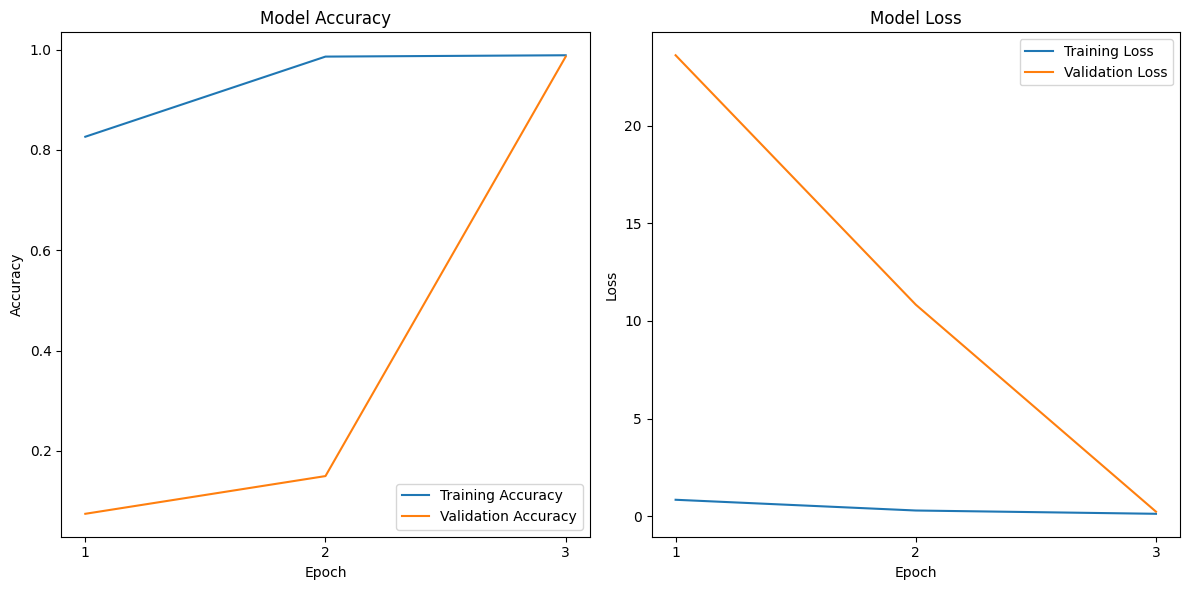

In [ ]:
# Plot training & validation accuracy values
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history_resnet3d['accuracy'], label='Training Accuracy')
plt.plot(history_resnet3d['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
# Change x-axis labels
plt.xticks([0, 1, 2], [1, 2, 3])  # Replace 0, 1, 2 with 1, 2, 3

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_resnet3d['loss'], label='Training Loss')
plt.plot(history_resnet3d['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
# Change x-axis labels
plt.xticks([0, 1, 2], [1, 2, 3])  # Replace 0, 1, 2 with 1, 2, 3
plt.tight_layout()
plt.show()

### CNN

CCN (3D Convolutional Neural Network) is a simplified deep learning model designed for processing 3D volumetric data, such as medical scans. The architecture consists of 3D convolutional layers followed by pooling layers, with a final fully connected output layer for classification.

Key features of CCN:

- 3D Convolutions: The model uses 3D convolutions to capture spatial patterns in 3D volumes, making it suitable for tasks like medical image analysis.
- Pooling Layers: Max pooling is applied to downsample the feature maps, helping reduce spatial dimensions and control overfitting.
- Dense Layer: The final dense layer outputs the class probabilities for each voxel or region in the image.
Softmax Activation: Softmax activation is used to output a normalized probability distribution across the possible classes.

In [ ]:
def CNN():
    # Define the input with the new shape (None, 60, 60, 36, 4)
    inputs = keras.Input((60, 60, 36, 4))

    # 3D convolution layer
    x = keras.layers.Conv3D(32, (1, 1, 1), padding='same')(inputs)
    x = keras.layers.Activation('relu')(x)
    x = keras.layers.MaxPooling3D(pool_size=(1, 1, 1), strides=(1, 1, 1), padding='same')(x)

    # Final dense layer
    outputs = keras.layers.Dense(out_chans, activation='softmax')(x)

    # Define the model
    net = keras.Model(inputs, outputs)

    return net


In [ ]:
cnn = CNN()
cnn.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 60, 60, 36, 4)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_9 (Conv3D)                    │ (None, 60, 60, 36, 32)      │             160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_7 (Activation)            │ (None, 60, 60, 36, 32)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling3d (MaxPooling3D)         │ (None, 60, 60, 36, 32)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 60, 60, 36, 4)       │             132 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 292 (1.14 KB)

 Trainable params: 292 (1.14 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile the model for training
cnn.compile(loss=keras.losses.categorical_crossentropy,
            optimizer=keras.optimizers.RMSprop(learning_rate=LEARNING_RATE),
            metrics=['accuracy'])

In [ ]:
if os.path.exists('C:/Users/giall/Desktop/Project/Proposta/History/history_CNN.pkl'):
    # Load the history object from the file
    with open('C:/Users/giall/Desktop/Project/Proposta/History/history_CNN.pkl', 'rb') as file:
        history_cnn = pickle.load(file)

    cnn = load_model('C:/Users/giall/Desktop/Project/Proposta/Model/CNN_new.h5')

else:
    # Model training. The datasets are divided into batches, each containing 4 samples.
    history_cnn = cnn.fit(
            dataset_training.batch(4),
            validation_data = dataset_validation.batch(4),
            epochs=NUM_EPOCH,
            verbose=1
    )

    # Save the history object to a file
    with open('C:/Users/giall/Desktop/Project/Proposta/History/history_CNN.pkl', 'wb') as file:
        pickle.dump(history_cnn.history, file)

    cnn.save('C:/Users/giall/Desktop/Project/Proposta/Model/CNN_new.h5')

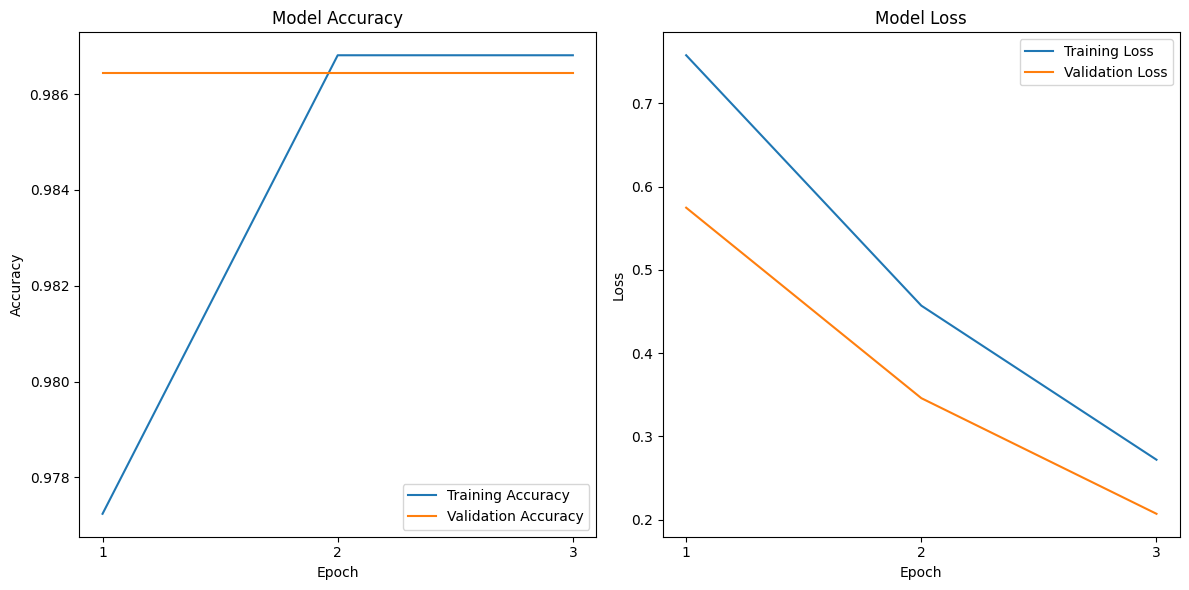

In [ ]:
# Plot training & validation accuracy values
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history_cnn['accuracy'], label='Training Accuracy')
plt.plot(history_cnn['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
# Change x-axis labels
plt.xticks([0, 1, 2], [1, 2, 3])  # Replace 0, 1, 2 with 1, 2, 3

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_cnn['loss'], label='Training Loss')
plt.plot(history_cnn['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
# Change x-axis labels
plt.xticks([0, 1, 2], [1, 2, 3])  # Replace 0, 1, 2 with 1, 2, 3
plt.tight_layout()
plt.show()

### CNN 2.0

In [ ]:
def CNN2():
    # Define the input shape directly within the function
    input_shape = (60, 60, 36, 4)  # Adjust input shape as needed

    # Create the model using Sequential
    model = Sequential()

    # Encoding Path
    model.add(Conv3D(32, kernel_size=(3, 3, 3), activation='relu', padding='same', input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(MaxPooling3D(pool_size=(2, 2, 2), padding='same'))
    model.add(Dropout(0.3))

    model.add(Conv3D(64, kernel_size=(3, 3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling3D(pool_size=(2, 2, 2), padding='same'))
    model.add(Dropout(0.3))

    model.add(Conv3D(128, kernel_size=(3, 3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling3D(pool_size=(3, 3, 3), padding='same'))

    # Decoding Path
    model.add(UpSampling3D(size=(3, 3, 3)))
    model.add(Conv3D(64, kernel_size=(3, 3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())

    model.add(UpSampling3D(size=(2, 2, 2)))
    model.add(Conv3D(32, kernel_size=(3, 3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())

    model.add(UpSampling3D(size=(2, 2, 2)))
    # model.add(Cropping3D(cropping=((0, 0), (0, 0), (2, 3))))  # Adjust cropping for target depth
    model.add(Conv3D(4, kernel_size=(1, 1, 1), activation='sigmoid', padding='same'))

    return model

In [ ]:
cnn2 = CNN2()
cnn2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv3d_39 (Conv3D)                   │ (None, 60, 60, 36, 32)      │           3,488 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_13               │ (None, 60, 60, 36, 32)      │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling3d_8 (MaxPooling3D)       │ (None, 30, 30, 18, 32)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 30, 30, 18, 32)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_40 (Conv3D)                   │ (None, 30, 30, 18, 64)      │          55,360 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_14               │ (None, 30, 30, 18, 64)      │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling3d_9 (MaxPooling3D)       │ (None, 15, 15, 9, 64)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 15, 15, 9, 64)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_41 (Conv3D)                   │ (None, 15, 15, 9, 128)      │         221,312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_15               │ (None, 15, 15, 9, 128)      │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling3d_10 (MaxPooling3D)      │ (None, 5, 5, 3, 128)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling3d_7 (UpSampling3D)       │ (None, 15, 15, 9, 128)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_42 (Conv3D)                   │ (None, 15, 15, 9, 64)       │         221,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_16               │ (None, 15, 15, 9, 64)       │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling3d_8 (UpSampling3D)       │ (None, 30, 30, 18, 64)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_43 (Conv3D)                   │ (None, 30, 30, 18, 32)      │          55,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_17               │ (None, 30, 30, 18, 32)      │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling3d_9 (UpSampling3D)       │ (None, 60, 60, 36, 32)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3d_44 (Conv3D)                   │ (None, 60, 60, 36, 4)       │             1

 Total params: 558,148 (2.13 MB)

 Trainable params: 557,508 (2.13 MB)

 Non-trainable params: 640 (2.50 KB)

In [ ]:
# Compile the model for training
cnn2.compile(loss=keras.losses.categorical_crossentropy,
            optimizer=keras.optimizers.RMSprop(learning_rate=LEARNING_RATE),
            metrics=['accuracy'])

In [ ]:
if os.path.exists('C:/Users/giall/Desktop/Project/Proposta/History/history_CNN_2.pkl'):
    # Load the history object from the file
    with open('C:/Users/giall/Desktop/Project/Proposta/History/history_CNN_2.pkl', 'rb') as file:
        history_cnn2 = pickle.load(file)

    cnn2 = load_model('C:/Users/giall/Desktop/Project/Proposta/Model/CNN_2.h5')

else:
    # Model training. The datasets are divided into batches, each containing 4 samples.
    history_cnn2 = cnn2.fit(
            dataset_training.batch(4),
            validation_data = dataset_validation.batch(4),
            epochs=NUM_EPOCH,
            verbose=1
    )

    # Save the history object to a file
    with open('C:/Users/giall/Desktop/Project/Proposta/History/history_CNN_2.pkl', 'wb') as file:
        pickle.dump(history_cnn2.history, file)

    cnn2.save('C:/Users/giall/Desktop/Project/Proposta/Model/CNN_2.h5')

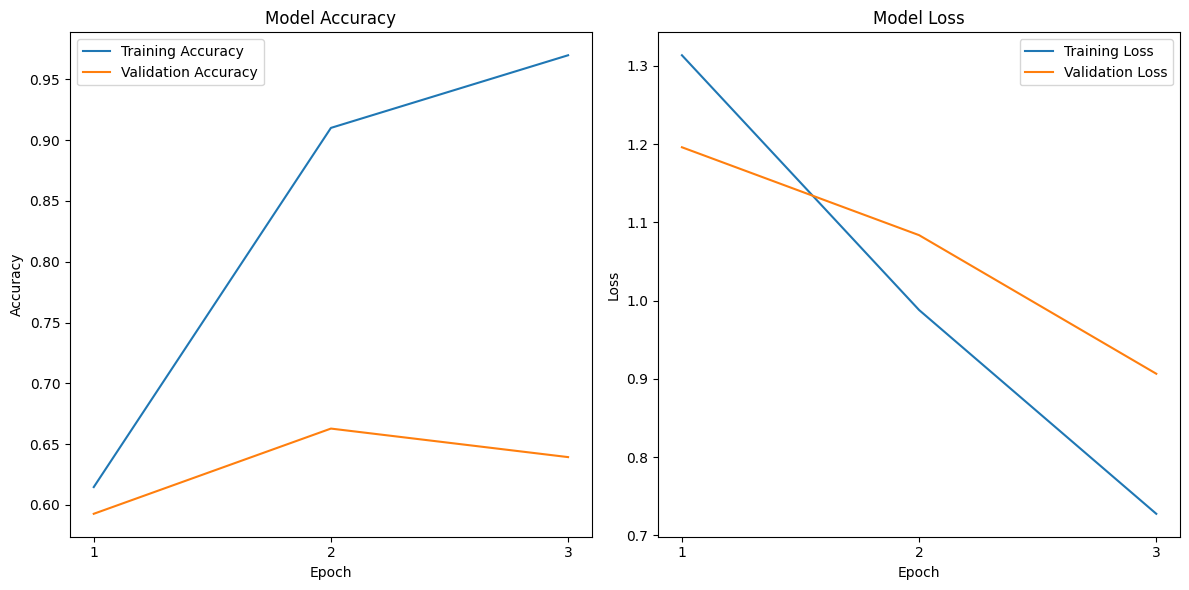

In [ ]:
# Plot training & validation accuracy values
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history_cnn2['accuracy'], label='Training Accuracy')
plt.plot(history_cnn2['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
# Change x-axis labels
plt.xticks([0, 1, 2], [1, 2, 3])  # Replace 0, 1, 2 with 1, 2, 3

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_cnn2['loss'], label='Training Loss')
plt.plot(history_cnn2['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
# Change x-axis labels
plt.xticks([0, 1, 2], [1, 2, 3])  # Replace 0, 1, 2 with 1, 2, 3
plt.tight_layout()
plt.show()

### UNet

UNet3D is a deep learning model specifically designed for 3D image segmentation tasks. It is an extension of the 2D U-Net architecture, incorporating 3D convolutions to handle volumetric data.

Key features of UNet3D:

- Encoder-Decoder Architecture: It uses an encoder to capture high-level features and a decoder to reconstruct spatial information, making it ideal for segmentation.
- 3D Convolutions: These convolutions enable the model to analyze 3D structures, like medical scans, by capturing spatial dependencies in three dimensions (depth, width, height).
- Skip Connections: Skip connections between encoder and decoder layers help retain fine-grained spatial details during the segmentation process.
- Applications: UNet3D is widely used in medical imaging for tasks such as organ and tumor segmentation, as well as other applications requiring detailed 3D segmentation.

In [ ]:
def UNet3D(input_shape, num_channels):
    inputs = layers.Input(shape=input_shape)

    # Encoder (Downsampling)
    conv1 = layers.Conv3D(64, (3, 3, 3), activation='relu', padding='same')(inputs)
    conv1 = layers.Conv3D(64, (3, 3, 3), activation='relu', padding='same')(conv1)
    pool1 = layers.MaxPooling3D(pool_size=(2, 2, 2))(conv1)

    conv2 = layers.Conv3D(128, (3, 3, 3), activation='relu', padding='same')(pool1)
    conv2 = layers.Conv3D(128, (3, 3, 3), activation='relu', padding='same')(conv2)
    pool2 = layers.MaxPooling3D(pool_size=(2, 2, 2))(conv2)

    conv3 = layers.Conv3D(256, (3, 3, 3), activation='relu', padding='same')(pool2)
    conv3 = layers.Conv3D(256, (3, 3, 3), activation='relu', padding='same')(conv3)
    pool3 = layers.MaxPooling3D(pool_size=(2, 2, 2))(conv3)

    conv4 = layers.Conv3D(512, (3, 3, 3), activation='relu', padding='same')(pool3)
    conv4 = layers.Conv3D(512, (3, 3, 3), activation='relu', padding='same')(conv4)
    pool4 = layers.MaxPooling3D(pool_size=(2, 2, 2))(conv4)

    # Bottleneck
    conv5 = layers.Conv3D(1024, (3, 3, 3), activation='relu', padding='same')(pool4)
    conv5 = layers.Conv3D(1024, (3, 3, 3), activation='relu', padding='same')(conv5)

    # Decoder (Upsampling)
    up6 = layers.UpSampling3D(size=(2, 2, 2))(conv5)
    up6 = layers.Conv3D(512, (2, 2, 2), activation='relu', padding='same')(up6)
    # Add ZeroPadding3D to make the upsampled tensor match the size of crop4
    up6 = layers.ZeroPadding3D(((0, 1), (0, 1), (0, 0)))(up6)  # Padding the first two dimensions by 1
    crop4 = layers.Cropping3D(cropping=((0, 0), (0, 0), (0, 0)))(conv4)
    up6 = layers.concatenate([up6, crop4], axis=-1)
    conv6 = layers.Conv3D(512, (3, 3, 3), activation='relu', padding='same')(up6)
    conv6 = layers.Conv3D(512, (3, 3, 3), activation='relu', padding='same')(conv6)

    up7 = layers.UpSampling3D(size=(2, 2, 2))(conv6)
    up7 = layers.Conv3D(256, (2, 2, 2), activation='relu', padding='same')(up7)
    # Add ZeroPadding3D to make the upsampled tensor match the size of crop4
    up7 = layers.ZeroPadding3D(((0, 1), (0, 1), (0, 1)))(up7)  # Padding the first two dimensions by 1
    crop3 = layers.Cropping3D(cropping=((0, 0), (0, 0), (0, 0)))(conv3)
    up7 = layers.concatenate([up7, crop3], axis=-1)
    conv7 = layers.Conv3D(256, (3, 3, 3), activation='relu', padding='same')(up7)
    conv7 = layers.Conv3D(256, (3, 3, 3), activation='relu', padding='same')(conv7)

    up8 = layers.UpSampling3D(size=(2, 2, 2))(conv7)
    up8 = layers.Conv3D(128, (2, 2, 2), activation='relu', padding='same')(up8)
    crop2 = layers.Cropping3D(cropping=((0, 0), (0, 0), (0, 0)))(conv2)
    up8 = layers.concatenate([up8, crop2], axis=-1)
    conv8 = layers.Conv3D(128, (3, 3, 3), activation='relu', padding='same')(up8)
    conv8 = layers.Conv3D(128, (3, 3, 3), activation='relu', padding='same')(conv8)

    up9 = layers.UpSampling3D(size=(2, 2, 2))(conv8)
    up9 = layers.Conv3D(64, (2, 2, 2), activation='relu', padding='same')(up9)
    crop1 = layers.Cropping3D(cropping=((0, 0), (0, 0), (0, 0)))(conv1)
    up9 = layers.concatenate([up9, crop1], axis=-1)
    conv9 = layers.Conv3D(64, (3, 3, 3), activation='relu', padding='same')(up9)
    conv9 = layers.Conv3D(64, (3, 3, 3), activation='relu', padding='same')(conv9)

    # Final output layer with 4 channels (as per your requirement)
    conv9 = layers.Conv3D(num_channels, (1, 1, 1), activation='sigmoid')(conv9)

    # Create model
    model = Model(inputs=inputs, outputs=conv9)

    return model

In [ ]:
# Create the UNet3D model
input_shape = (60, 60, 36, 4)
unet3d = UNet3D(input_shape, out_chans)

unet3d.summary()

Model: "functional_40"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)    │ (None, 60, 60, 36, 4)     │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv3d_16 (Conv3D)            │ (None, 60, 60, 36, 64)    │           6,976 │ input_layer_3[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv3d_17 (Conv3D)            │ (None, 60, 60, 36, 64)    │         110,656 │ conv3d_16[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling3d_4               │ (None, 30, 30, 18, 64)    │               0 │ conv3d_17[0][0]            │
│ (MaxPooling3D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv3d_18 (Conv3D)            │ (None, 30, 30, 18, 128)   │         221,312 │ max_pooling3d_4[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv3d_19 (Conv3D)            │ (None, 30, 30, 18, 128)   │         442,496 │ conv3d_18[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling3d_5               │ (None, 15, 15, 9, 128)    │               0 │ conv3d_19[0][0]            │
│ (MaxPooling3D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv3d_20 (Conv3D)            │ (None, 15, 15, 9, 256)    │         884,992 │ max_pooling3d_5[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv3d_21 (Conv3D)            │ (None, 15, 15, 9, 256)    │       1,769,728 │ conv3d_20[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling3d_6               │ (None, 7, 7, 4, 256)      │               0 │ conv3d_21[0][0]            │
│ (MaxPooling3D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv3d_22 (Conv3D)            │ (None, 7, 7, 4, 512)      │       3,539,456 │ max_pooling3d_6[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv3d_23 (Conv3D)            │ (None, 7, 7, 4, 512)      │       7,078,400 │ conv3d_22[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling3d_7               │ (None, 3, 3, 2, 512)      │               0 │ conv3d_23[0][0]            │
│ (MaxPooling3D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv3d_24 (Conv3D)            │ (None, 3, 3, 2, 1024)     │      14,156,800 │ max_pooling3d_7[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv3d_25 (Conv3D)            │ (None, 3, 3, 2, 1024)     │      28,312,576 │ conv3d_24[0][0]            │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 90,298,052 (344.46 MB)

 Trainable params: 90,298,052 (344.46 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
unet3d.compile(
    loss='categorical_crossentropy',
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    metrics=['accuracy']
)

In [ ]:
if os.path.exists('C:/Users/giall/Desktop/Project/Proposta/History/history_unet3d.pkl'):
    # Load the history object from the file
    with open('C:/Users/giall/Desktop/Project/Proposta/History/history_unet3d.pkl', 'rb') as file:
        history_unet3d = pickle.load(file)

    unet3d = tf.keras.models.load_model('C:/Users/giall/Desktop/Project/Proposta/Model/UNet.h5')
else:
    # Model training. The datasets are divided into batches, each containing 2 samples.
    history_unet3d = unet3d.fit(
        dataset_training.batch(2),
        validation_data = dataset_validation.batch(2),
        epochs = NUM_EPOCH,
        verbose = 1,
    )

    # Save the history object to a file
    with open('C:/Users/giall/Desktop/Project/Proposta/History/history_unet3d.pkl', 'wb') as file:
        pickle.dump(history_unet3d.history, file)

    unet3d.save('C:/Users/giall/Desktop/Project/Proposta/Model/UNet.h5')

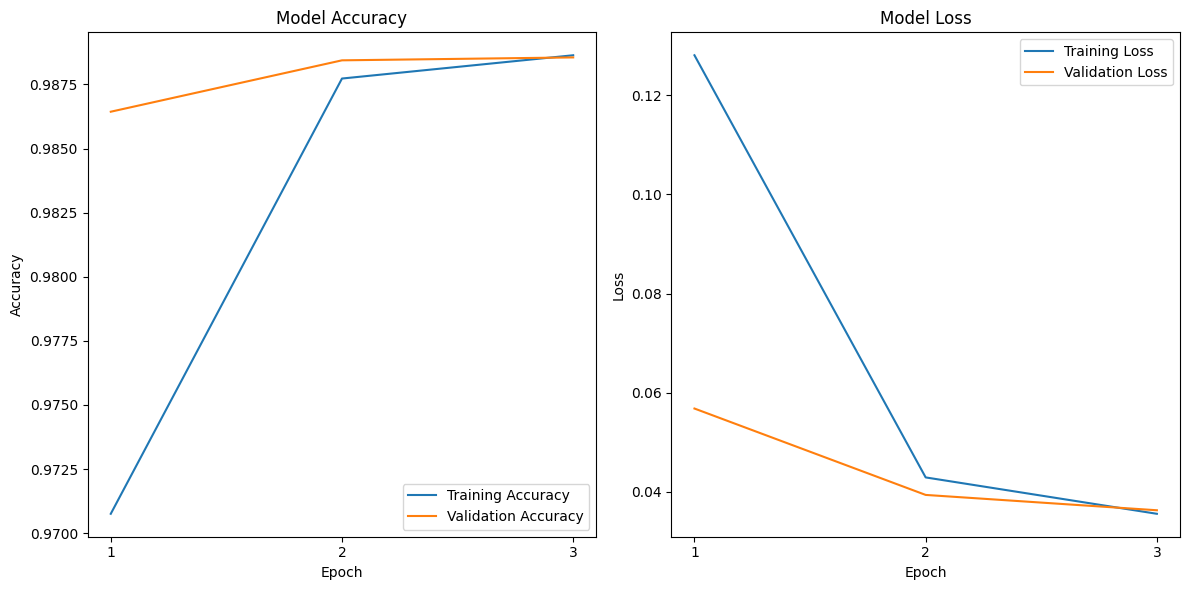

In [ ]:
# Plot training & validation accuracy values
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history_unet3d['accuracy'], label='Training Accuracy')
plt.plot(history_unet3d['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
# Change x-axis labels
plt.xticks([0, 1, 2], [1, 2, 3])  # Replace 0, 1, 2 with 1, 2, 3

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_unet3d['loss'], label='Training Loss')
plt.plot(history_unet3d['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
# Change x-axis labels
plt.xticks([0, 1, 2], [1, 2, 3])  # Replace 0, 1, 2 with 1, 2, 3
plt.tight_layout()
plt.show()

## Models evaluation

In [ ]:
class_names = [
    "0: background",
    "1: oedema",
    "2: necrotic",
    "3: Gd Enhancing",
]

In [ ]:
# Function to plot the confusion matrix
def plot_confusion_matrix(conf_matrix, class_names):
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.title("Confusion Matrix")
    plt.show()

# Function to retrieve predictions and labels from the dataset
def get_predictions_and_labels(model, dataset):
    predictions = []
    labels = []
    for image_batch, label_batch in dataset:
        # Generate predictions
        preds = model.predict(image_batch)
        # Convert predictions from one-hot encoding to class indices
        preds_classes = np.argmax(preds, axis=-1).flatten()
        # Convert labels from one-hot encoding to class indices
        labels_classes = np.argmax(label_batch.numpy(), axis=-1).flatten()
        predictions.extend(preds_classes)
        labels.extend(labels_classes)
    return np.array(predictions), np.array(labels)


### ResNet

In [ ]:
# Get predictions and labels from the testing dataset
predictions, labels = get_predictions_and_labels(resnet3d, dataset_testing.batch(4))

# Compute the confusion matrix
conf_matrix = confusion_matrix(labels, predictions)

# Print the confusion matrix
print("Confusion Matrix:")
print(conf_matrix)

# Print a detailed classification report
print("\nClassification Report:")
print(classification_report(labels, predictions))

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 891ms/step
Confusion Matrix:
[[3197480     492     458     257]
 [  19334     763     813      24]
 [  11975    1300     324     118]
 [   5852     720      58      32]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99   3198687
           1       0.23      0.04      0.06     20934
           2       0.20      0.02      0.04     13717
           3       0.07      0.00      0.01      6662

    accuracy                           0.99   3240000
   macro avg       0.37      0.27      0.28   3240000
weighted avg       0.98      0.99      0.98   3240000



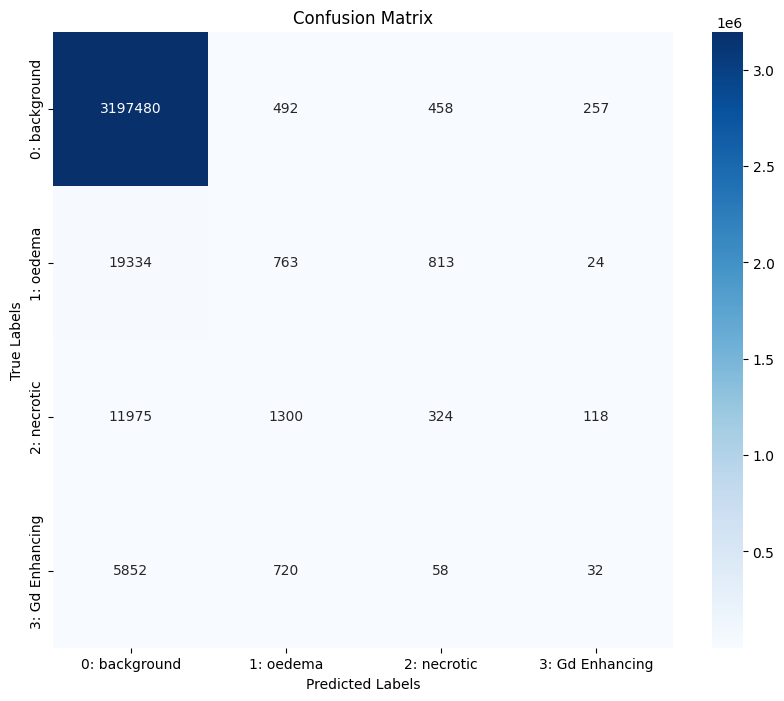

In [ ]:
# Plot of the confusion matrix
plot_confusion_matrix(conf_matrix, class_names)

### CNN

In [ ]:
# Get predictions and labels from the testing dataset
predictions, labels = get_predictions_and_labels(cnn, dataset_testing.batch(4))

# Compute the confusion matrix
conf_matrix = confusion_matrix(labels, predictions)

# Print the confusion matrix
print("Confusion Matrix:")
print(conf_matrix)

# Print a detailed classification report
print("\nClassification Report:")
print(classification_report(labels, predictions))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Confusion Matrix:
[[3198388     254       0      45]
 [  19911     910       0     113]
 [  13081     228       0     408]
 [   6411     191       0      60]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99   3198687
           1       0.57      0.04      0.08     20934
           2       0.00      0.00      0.00     13717
           3       0.10      0.01      0.02      6662

    accuracy                           0.99   3240000
   macro avg       0.41      0.26      0.27   3240000
weighted avg       0.98      0.99      0.98   3240000



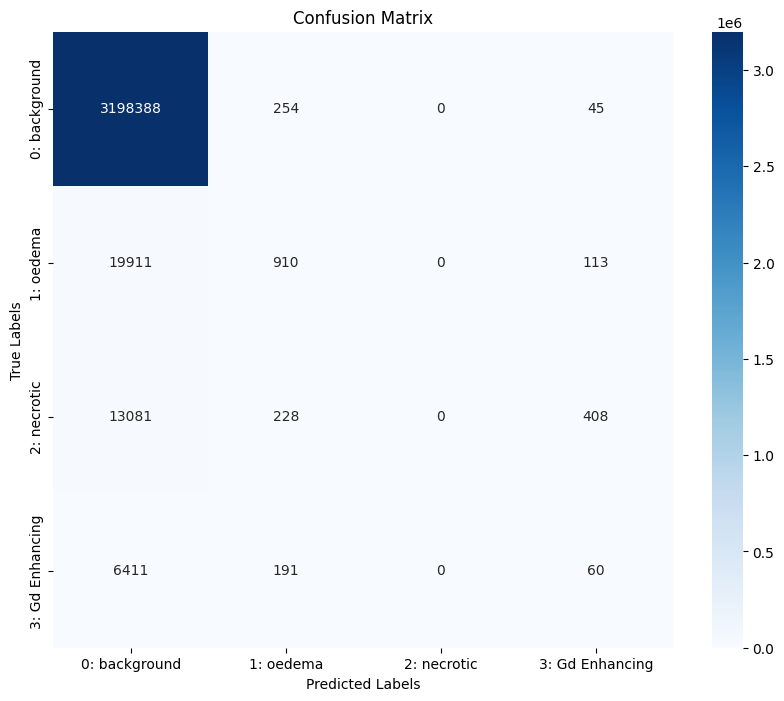

In [ ]:
# Plot of the confusion matrix
plot_confusion_matrix(conf_matrix, class_names)

### CNN 2.0

In [ ]:
# Get predictions and labels from the testing dataset
predictions, labels = get_predictions_and_labels(cnn2, dataset_testing.batch(4))

# Compute the confusion matrix
conf_matrix = confusion_matrix(labels, predictions)

# Print the confusion matrix
print("Confusion Matrix:")
print(conf_matrix)

# Print a detailed classification report
print("\nClassification Report:")
print(classification_report(labels, predictions))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
Confusion Matrix:
[[1031238       0     175 2167274]
 [   9454       0     832   10648]
 [   6481       0     190    7046]
 [   3515       0     179    2968]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.32      0.49   3198687
           1       0.00      0.00      0.00     20934
           2       0.14      0.01      0.03     13717
           3       0.00      0.45      0.00      6662

    accuracy                           0.32   3240000
   macro avg       0.28      0.20      0.13   3240000
weighted avg       0.97      0.32      0.48   3240000



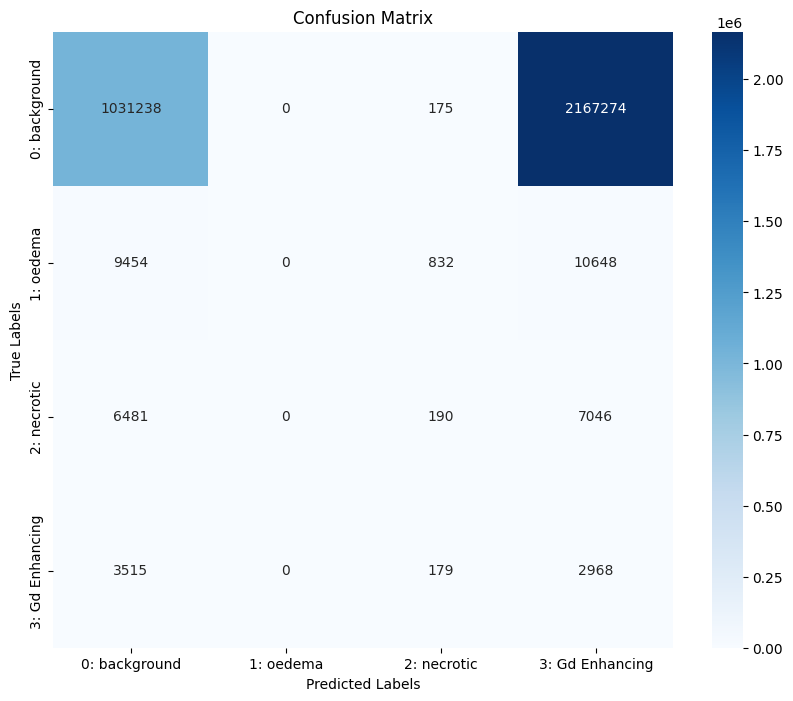

In [ ]:
# Plot of the confusion matrix
plot_confusion_matrix(conf_matrix, class_names)

### UNet

In [ ]:
# Get predictions and labels from the testing dataset
predictions, labels = get_predictions_and_labels(unet3d, dataset_testing.batch(4))

# Compute the confusion matrix
conf_matrix = confusion_matrix(labels, predictions)

# Print the confusion matrix
print("Confusion Matrix:")
print(conf_matrix)

# Print a detailed classification report
print("\nClassification Report:")
print(classification_report(labels, predictions))


1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Confusion Matrix:
[[3194367    2898    1422       0]
 [  12377    3796    4761       0]
 [   4343    3944    5430       0]
 [   2314    1586    2762       0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00   3198687
           1       0.31      0.18      0.23     20934
           2       0.38      0.40      0.39     13717
           3       0.00      0.00      0.00      6662

    accuracy                           0.99   3240000
   macro avg       0.42      0.39      0.40   3240000
weighted avg       0.99      0.99      0.99   3240000



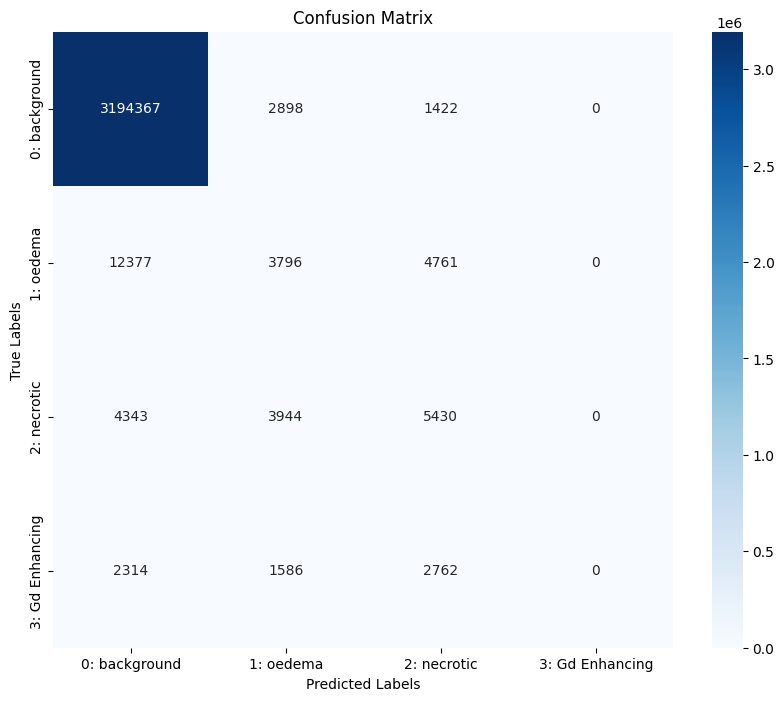

In [ ]:
# Plot of the confusion matrix
plot_confusion_matrix(conf_matrix, class_names)

## BINARY PROBLEM

We recreate the data for a second type of problem

Let's also analyze a second type of problem, where instead of identifying the different parts of the tumor, we will create a neural network that simply distinguishes between background and tumor. This will allow us to have additional control over the images we visualize. The purpose of this analysis is to provide a preliminary diagnosis on the presence or absence of a tumor, for subsequent further analysis. To carry out this part, a different type of preprocessing will be necessary.

In [61]:
# Upload the GBM files
files_GBM, count_GBM, example_GBM = load_files(file_path_GBM, channel_names, channel_truth)
print(f"Found {count_GBM} sets of files_GBM")

# Upload the LLG files
files_LGG, count_LGG, example_LGG = load_files(file_path_LGG, channel_names, channel_truth)
print(f"Found {count_LGG} sets of files_LGG")

Found 102 sets of files_GBM
Found 65 sets of files_LGG


In [62]:
files = files_LGG + files_GBM
# Shuffles the files list
random.shuffle(files)
print(f"The number of patient is: {len(files)}")

The number of patient is: 167


In [63]:
# Create two lists: one for the "truth" files and one for the remaining files without the "truth" file.

# List to store the "truth" files
files_truth = []

# List to store the remaining files
files_remaining = []

# Modify the existing list by removing the "truth" files and adding them to `files_truth`
for files_dict in files:
    files_dict_copy = files_dict.copy()

    if 'truth.nii.gz' in files_dict_copy:
        files_truth.append(files_dict_copy.pop('truth.nii.gz'))
        files_remaining.append(files_dict_copy)  # Add the dictionary without the "truth" file

# Verify the results
print(f"Found {len(files_truth)} truth files and {len(files_remaining)} sets of remaining files")
print("Example truth file and remaining files:")
print("{'truth.nii.gz': '" + files_truth[0] + "'}")
files_remaining[0]

Found 167 truth files and 167 sets of remaining files
Example truth file and remaining files:
{'truth.nii.gz': '/content/drive/MyDrive/BRATS/Pre-operative_TCGA_LGG_NIfTI_and_Segmentations/TCGA-DU-7015/truth.nii.gz'}


{'flair.nii.gz': '/content/drive/MyDrive/BRATS/Pre-operative_TCGA_LGG_NIfTI_and_Segmentations/TCGA-DU-7015/flair.nii.gz',
 't1.nii.gz': '/content/drive/MyDrive/BRATS/Pre-operative_TCGA_LGG_NIfTI_and_Segmentations/TCGA-DU-7015/t1.nii.gz',
 't1ce.nii.gz': '/content/drive/MyDrive/BRATS/Pre-operative_TCGA_LGG_NIfTI_and_Segmentations/TCGA-DU-7015/t1ce.nii.gz',
 't2.nii.gz': '/content/drive/MyDrive/BRATS/Pre-operative_TCGA_LGG_NIfTI_and_Segmentations/TCGA-DU-7015/t2.nii.gz'}

In [64]:
# These variables define the proportions of the dataset to be used for training, testing, and validation.
PERCENT_TRAINING = 0.8
PERCENT_TESTING = 0.1
PERCENT_VALIDATION = 0.1

In [ ]:
n_train = round(PERCENT_TRAINING*len(files))
n_test = round(PERCENT_TESTING*len(files))
n_val = round(PERCENT_VALIDATION*len(files))

# Ensures that the sum of the datasets equals the total number of files available. If not, the difference is added to the training set
total_count = n_train + n_test + n_val
if total_count != len(files):
    difference = len(files) - total_count
    n_train += difference

In [65]:
files_training = files_remaining[:n_train]
files_truth_training = files_truth[:n_train]

files_testing = files_remaining[n_train:n_train + n_test]
files_truth_testing = files_truth[n_train:n_train + n_test]

files_validation = files_remaining[n_train + n_test:]
files_truth_validation = files_truth[n_train + n_test:]

### BINARY PREPROCESSING

In [66]:
dimension_image_binary = (60, 60, 36, 2)
dimension_net_input = tf.TensorSpec(dimension_image_binary, dtype=np.float32)
dimension_net_output = tf.TensorSpec(dimension_image_binary, dtype=np.float32)
generator_output_signature = (dimension_net_input, dimension_net_output)
generator_output_signature

(TensorSpec(shape=(60, 60, 36, 2), dtype=tf.float32, name=None),
 TensorSpec(shape=(60, 60, 36, 2), dtype=tf.float32, name=None))

In [67]:
#we modify this function to create a new type of dataset to the binary problem
def load_image_bin(path_truth: str, path_channels: dict[str, str]) -> tuple[np.ndarray, np.ndarray]:
    image_tensor = np.zeros(dimension_image_binary, dtype=np.float32)
    for channel, path in path_channels.items():
        try:
          image_tensor[:,:,:,channel_to_dimension[channel]] = load_channel(path)
        except:
          pass
    return load_channel(path_truth), image_tensor
def truth_to_boolean_bin(truth_tensor: np.ndarray) -> np.ndarray:
    # prepare to use keras to_categorical, which creates a class for every int value
    truth_tensor[truth_tensor > 0.5] = 1

    return keras.utils.to_categorical(truth_tensor, num_classes = 2)


In [68]:

def get_dataset_generator_mix_max(files_truth_list: list[str], files_input_list: list[dict[str,str]], augmentation = False):

    # Generates data without applying augmentation. The data will be fed to the network
    def dataset_generator_without_augmentation():
        for i in range(len(files_truth_list)):
            # Load and preprocess tensors
            truth_tensor, image_tensor = load_image_bin(files_truth_list[i], files_input_list[i])
            #image_tensor = intensity_avg_all(image_tensor)
            image_tensor = min_max_all(image_tensor)
            truth_tensor = truth_to_boolean_bin(truth_tensor)
            yield tf.convert_to_tensor(image_tensor), tf.convert_to_tensor(truth_tensor)

    # Generates data with augmentation. The data will be fed to the network
    def dataset_generator_with_augmentation():
        for i in range(len(files_truth_list)):
            # Load and preprocess tensors
            truth_tensor, image_tensor = load_image_bin(files_truth_list[i], files_input_list[i])
            #image_tensor = intensity_avg_all(image_tensor)
            image_tensor = min_max_all(image_tensor)
            truth_tensor = truth_to_boolean_bin(truth_tensor)
            truth_tensor, image_tensor = data_augmentation(truth_tensor, image_tensor)
            yield tf.convert_to_tensor(image_tensor), tf.convert_to_tensor(truth_tensor)

    # Choose generator based on augmentation flag
    return dataset_generator_with_augmentation if augmentation else dataset_generator_without_augmentation

#print(get_dataset_generator(files_truth, files_remaining)().send(None))

def get_dataset_generator_average_bin(files_truth_list: list[str], files_input_list: list[dict[str,str]], augmentation = False):

    # Generates data without applying augmentation. The data will be fed to the network
    def dataset_generator_without_augmentation():
        for i in range(len(files_truth_list)):
            # Load and preprocess tensors
            truth_tensor, image_tensor = load_image_bin(files_truth_list[i], files_input_list[i])
            #image_tensor = min_max_all(image_tensor)
            image_tensor = intensity_avg_all(image_tensor)
            truth_tensor = truth_to_boolean_bin(truth_tensor)
            yield tf.convert_to_tensor(image_tensor), tf.convert_to_tensor(truth_tensor)

    # Generates data with augmentation. The data will be fed to the network
    def dataset_generator_with_augmentation():
        for i in range(len(files_truth_list)):
            # Load and preprocess tensors
            truth_tensor, image_tensor = load_image_bin(files_truth_list[i], files_input_list[i])
            image_tensor = intensity_avg_all(image_tensor)
            #image_tensor = min_max_all(image_tensor)
            truth_tensor = truth_to_boolean_bin(truth_tensor)
            truth_tensor, image_tensor = data_augmentation(truth_tensor, image_tensor)
            yield tf.convert_to_tensor(image_tensor), tf.convert_to_tensor(truth_tensor)

    # Choose generator based on augmentation flag
    return dataset_generator_with_augmentation if augmentation else dataset_generator_without_augmentation

#print(get_dataset_generator(files_truth, files_remaining)().send(None))
#

#print(get_dataset_generator(files_truth, files)().send(None))


In [69]:
# This code creates TensorFlow datasets for training, testing, and validation from the respective file lists using the `get_dataset_generator` function.
# It specifies the output signature of the dataset and sets the cardinality to ensure the dataset size matches the number of files provided, which helps with progress tracking and dataset consistency.

dataset_training_mix_max = tf.data.Dataset.from_generator(
    get_dataset_generator_mix_max(files_truth_training, files_training, augmentation = False),
    output_signature = generator_output_signature,)
dataset_training_mix_max = dataset_training_mix_max.apply(tf.data.experimental.assert_cardinality(len(files_training)))


dataset_testing_mix_max = tf.data.Dataset.from_generator(
    get_dataset_generator_mix_max(files_truth_testing, files_testing, augmentation = False),
    output_signature = generator_output_signature,
)
dataset_testing_mix_max = dataset_testing_mix_max.apply(tf.data.experimental.assert_cardinality(len(files_testing)))

dataset_validation_mix_max = tf.data.Dataset.from_generator(
    get_dataset_generator_mix_max(files_truth_validation, files_validation, augmentation = False),
    output_signature = generator_output_signature,
)
dataset_validation_mix_max = dataset_validation_mix_max.apply(tf.data.experimental.assert_cardinality(len(files_validation)))

In [70]:
dataset_training_bin = tf.data.Dataset.from_generator(
    get_dataset_generator_average_bin(files_truth_training, files_training, augmentation = False),
    output_signature = generator_output_signature,)
dataset_training_bin  = dataset_training_bin.apply(tf.data.experimental.assert_cardinality(len(files_training)))


dataset_testing_bin  = tf.data.Dataset.from_generator(
    get_dataset_generator_average_bin(files_truth_testing, files_testing, augmentation = False),
    output_signature = generator_output_signature,
)
dataset_testing_bin = dataset_testing_bin.apply(tf.data.experimental.assert_cardinality(len(files_testing)))

dataset_validation_bin = tf.data.Dataset.from_generator(
    get_dataset_generator_average_bin(files_truth_validation, files_validation, augmentation = False),
    output_signature = generator_output_signature,
)
dataset_validation_bin = dataset_validation_bin.apply(tf.data.experimental.assert_cardinality(len(files_validation)))

In [71]:
batch_size = 4

dataset_training_batched_mix_max = dataset_training_mix_max.batch(batch_size)
dataset_testing_batched_mix_max = dataset_testing_mix_max.batch(batch_size)
dataset_validation_batched_mix_max = dataset_validation_mix_max.batch(batch_size)

dataset_training_batched_bin = dataset_training_bin.batch(batch_size)
dataset_testing_batched_bin = dataset_testing_bin.batch(batch_size)
dataset_validation_batched_bin = dataset_validation_bin.batch(batch_size)

In [72]:
num_epoch = 10
learning_rate = 1.0

inputs = keras.Input(dimension_image_binary)
out_chans = dimension_image_binary[3]

In [73]:
def ResNet3D_binary():
    x = inputs

    # Convolutional layer
    x = keras.layers.Conv3D(16, kernel_size=3, activation="relu", strides=1, padding='same')(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Activation('relu')(x)

    x = residual_block_2(x, filters=16, strides=1)
    x = residual_block_2(x, filters=16)


    # Convolutional layer output
    outputs = keras.layers.Conv3D(out_chans, kernel_size=1, activation='softmax')(x)

    model = keras.models.Model(inputs, outputs)
    return model

In [ ]:
#model mix max
resnet3d_b = ResNet3D_binary()
resnet3d_b.compile(
    loss='categorical_crossentropy',
    optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
    metrics=['accuracy']
    #loss_weights=class_weights

)
num_epoch_ridotte = 3

history_resnet3d_b = resnet3d_b.fit(
    dataset_training_batched_mix_max,
    validation_data = dataset_validation_batched_mix_max,
    epochs = num_epoch_ridotte,
    verbose = 1,
)
# put path to save the model
#resnet3d_b.save('C:/Users/giall/Desktop/Project/Proposta/resnet3d_b_2.h5')

In [ ]:
#model average
resnet3d = ResNet3D_binary()
resnet3d.compile(
    loss='categorical_crossentropy',
    optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
    metrics=['accuracy']
    #loss_weights=class_weights

)
num_epoch_ridotte = 3

history_resnet3d = resnet3d.fit(
    dataset_training_batched_bin,
    validation_data = dataset_validation_batched_bin,
    epochs = num_epoch_ridotte,
    verbose = 1,
)

# inserrie percorso
#resnet3d.save('/content/drive/MyDrive/ResNet_04_01_2025_BINARY_BATCH')

### evaluation binary model


In [74]:
# funzioni che ci permettono di analizzare i vari modelli
val1 = 60
val2 = 36
def calcolo_preds(preds):
  A = 0
  B = 0
  C = 0
  D = 0
  lista = []
  for w in range(preds.shape[0]):
    for k in range(val1):
      for x in range(val1):
        for j in range(val2):
          A = preds[w][k][x][j][0]
          B = preds[w][k][x][j][1]
          C = preds[w][k][x][j][2]
          D = preds[w][k][x][j][3]
          if A > B and A > C and A > D:
            lista.append(1)
          elif B > C and B > D:
            lista.append(2)
          elif C > D:
            lista.append(3)
          else:
            lista.append(4)
  return lista

def calcolo_label(label):
  flattened_dim = label.shape[0] * label.shape[1] * label.shape[2] * label.shape[3]

  flat = np.reshape(label.numpy(), (flattened_dim, 4))

  return flat

def calcolo_preds_bin(preds):
  A = 0
  B = 0

  lista = []
  for w in range(preds.shape[0]):
    for k in range(val1):
      for x in range(val1):
        for j in range(val2):
          A = preds[w][k][x][j][0]
          B = preds[w][k][x][j][1]

          if A > B :
            lista.append(1)

          else:
            lista.append(2)
  return lista

def calcolo_label_bin(label):
  flattened_dim = label.shape[0] * label.shape[1] * label.shape[2] * label.shape[3]

  flat = np.reshape(label.numpy(), (flattened_dim, 2))

  return flat


def etichette_lab(lis):
  lista = []
  dim = len(lis)
  for x in range(dim):
    if lis[x][0] > 0:
      lista.append(1)
    if lis[x][1] > 0:
      lista.append(2)
    if lis[x][2] > 0:
      lista.append(3)
    if lis[x][3] > 0:
      lista.append(4)
  return lista

def etichette_lab_bin(lis):
  lista = []
  dim = len(lis)
  for x in range(dim):
    if lis[x][0] > 0:
      lista.append(1)
    if lis[x][1] > 0:
      lista.append(2)

  return lista

In [48]:
dataset_testing_batched_mix_max

<_BatchDataset element_spec=(TensorSpec(shape=(None, 60, 60, 36, 4), dtype=tf.float32, name=None), TensorSpec(shape=(None, 60, 60, 36, 4), dtype=tf.float32, name=None))>

In [77]:
# valutazione modello mix_max
resnet3d_binary = load_model('/content/Resnet_binary_average.h5')
modelli = [resnet3d_binary]
for x in modelli:
    raw_preds = []
    flat_truth = []
    conta = 0 # contatore per il controllo del batch
    for dataset,label in dataset_testing_batched_mix_max:
        preds = x.predict(x=dataset, verbose=0) # predizione sul testing
        pre = calcolo_preds_bin(preds)  # trasformazione delle predizioni in etichette per
        raw_preds.extend(pre)

        fixed = label  # truth labels
        fixed_label = calcolo_label_bin(fixed)
        flat_truth.extend(fixed_label)
        conta = conta +1

    #rendiamo le flat_truth delle ettichette, passando da array ad interi
    truth = etichette_lab_bin(flat_truth)
    # Supponiamo di avere queste etichette vere e predette:
    y_true = truth
    y_pred = raw_preds

    # Creiamo la matrice di confusione
    legenda = [1,2,3,4]
    cm = confusion_matrix(y_true, y_pred)#, label = legenda)

    print(f"Matrice di Confusione del modello resnet_bin:")
    print(cm)
bin_class_names = [
    "0: background",
    "1: tumor"
]
plot_confusion_matrix(cm, bin_class_names)


Matrice di Confusione del modello resnet_bin:
[[2170630       0]
 [  32570       0]]


NameError: name 'plot_confusion_matrix' is not defined

In [69]:
dataset_testing_batched_mix_max

<_BatchDataset element_spec=(TensorSpec(shape=(None, 60, 60, 36, 4), dtype=tf.float32, name=None), TensorSpec(shape=(None, 60, 60, 36, 4), dtype=tf.float32, name=None))>

In [76]:
# valutazione modello average
resnet3d_binary = load_model('/content/Resnet_binary_average.h5')
modelli = [resnet3d_binary]
for x in modelli:
    raw_preds = []
    flat_truth = []
    conta = 0 # contatore per il controllo del batch
    for dataset,label in dataset_testing_batched_bin:
        preds = x.predict(x=dataset, verbose=0) # predizione sul testing
        pre = calcolo_preds_bin(preds)  # trasformazione delle predizioni in etichette per
        raw_preds.extend(pre)

        fixed = label  # truth labels
        fixed_label = calcolo_label_bin(fixed)
        flat_truth.extend(fixed_label)
        conta = conta +1

    #rendiamo le flat_truth delle ettichette, passando da array ad interi
    truth = etichette_lab_bin(flat_truth)
    # Supponiamo di avere queste etichette vere e predette:
    y_true = truth
    y_pred = raw_preds

    # Creiamo la matrice di confusione
    legenda = [1,2,3,4]
    cm = confusion_matrix(y_true, y_pred)#, label = legenda)

    print(f"Matrice di Confusione del modello resnet_bin:")
    print(cm)
bin_class_names = [
    "0: background",
    "1: tumor"
]
plot_confusion_matrix(cm, bin_class_names)


Matrice di Confusione del modello resnet_bin:
[[2170629       1]
 [  29957    2613]]


NameError: name 'plot_confusion_matrix' is not defined